# CS436 Computer Vision Project - Week 1 Deliverable


**Student:** Muhammad Zain Naseer , Kousar Pervaiz



In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from itertools import product
from PIL import Image
from PIL.ExifTags import TAGS
import open3d as o3d

from scipy.optimize import least_squares
from collections import defaultdict
import pickle
import os


plt.rcParams['figure.figsize'] = (12, 10)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Load Image Dataset



In [6]:

IMAGE_DIR = r"images"  


image_paths = sorted(glob.glob(f"{IMAGE_DIR}/*.jpg"))

print(f"{len(image_paths)} images")

26 images


In [7]:

images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  
    else:
        print(f"Warning: Could not load {path}")

print(f"Loaded {len(images)} images successfully")
if len(images) > 0:
    print(f"Image shape: {images[0].shape}")

Loaded 26 images successfully
Image shape: (8160, 6120, 3)


## 2. Display Image Grid (10 Images)

Displaying a grid of 10 images from the dataset to show the variety of viewpoints.

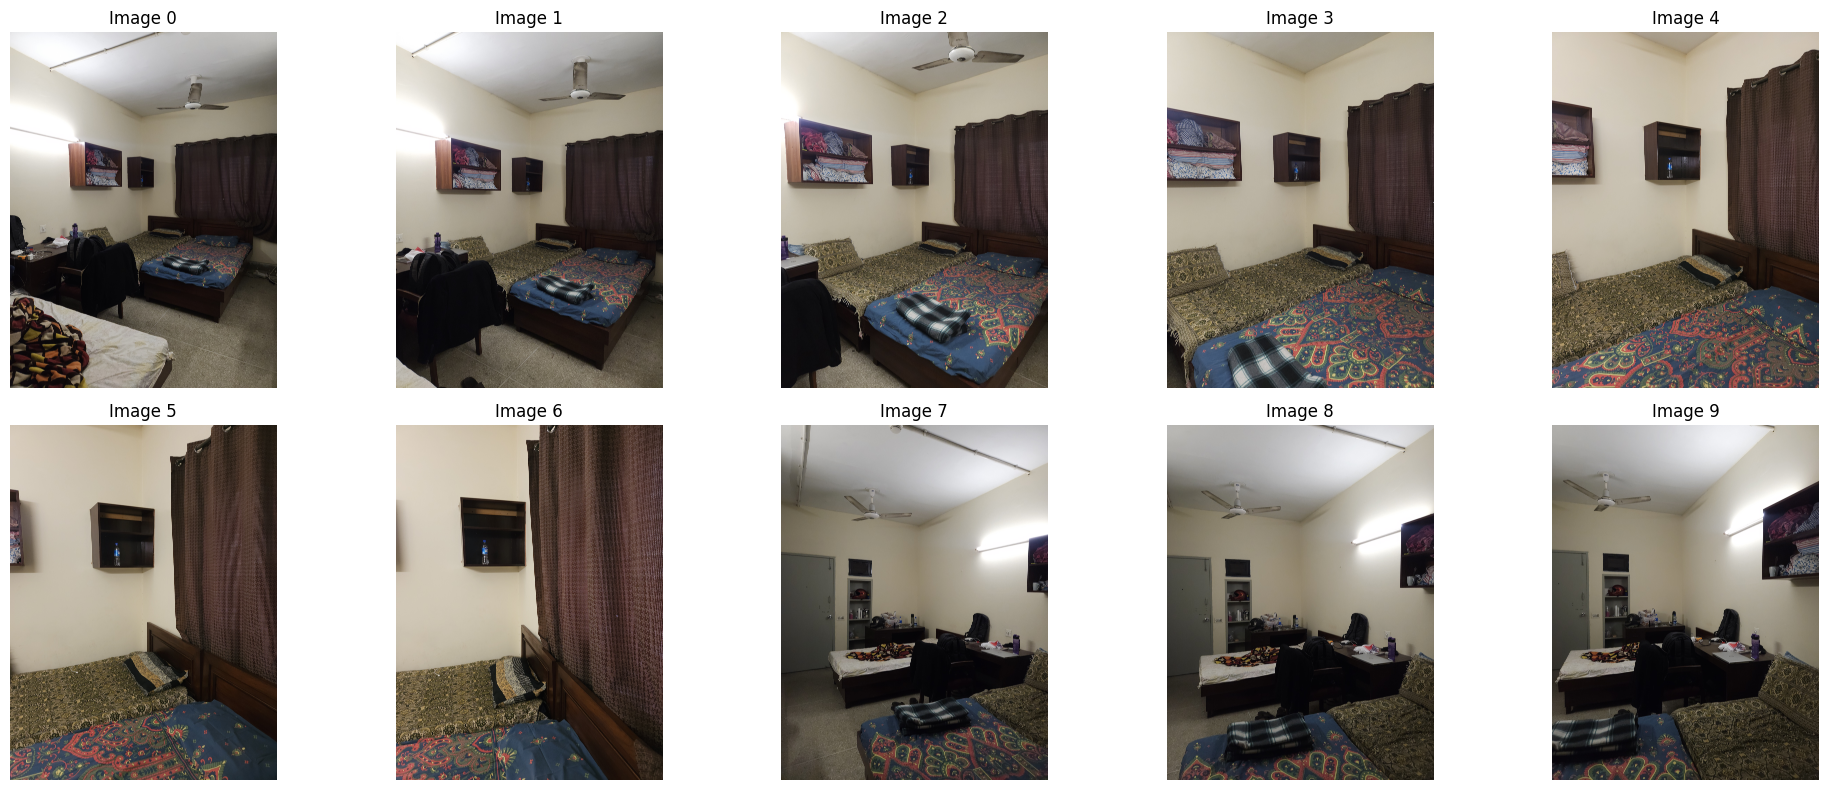

In [8]:
def display_image_grid(images, n_images, cols):

    n_images = min(n_images, len(images))
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for i in range(n_images):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Image {i}', fontsize=12)
        axes[i].axis('off')
    

    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

display_image_grid(images, n_images=10, cols=5)

## 3. Image Preprocessing



In [9]:
def preprocess_image(img, target_width=1920, convert_to_gray=True):

    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    

    h, w = img_bgr.shape[:2]
    if w > target_width:
        scale = target_width / w
        new_w = int(w * scale)
        new_h = int(h * scale)
        img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    

    

    if convert_to_gray:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
     
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


if len(images) > 0:
    sample_img = images[0]
    print(f"Original image shape: {sample_img.shape}")
    

    preprocessed_images = []
    for img in images:
        preprocessed = preprocess_image(img, convert_to_gray=True)
        preprocessed_images.append(preprocessed)
    
    print(f"Preprocessed {len(preprocessed_images)} images")
    print(f"Preprocessed image shape: {preprocessed_images[0].shape}")
    print(f"Image is now grayscale: {len(preprocessed_images[0].shape) == 2}")
else:
    preprocessed_images = images
    print("No preprocessing applied (using original images)")

Original image shape: (8160, 6120, 3)
Preprocessed 26 images
Preprocessed image shape: (2560, 1920)
Image is now grayscale: True


## 4. Feature Detection and Matching

Using SIFT (Scale-Invariant Feature Transform) to detect and match features between consecutive images.

### 4.1 Feature Detection Setup

In [10]:

sift = cv2.SIFT_create(nfeatures=10000)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

print("Feature detector and matcher initialized")

Feature detector and matcher initialized


### 4.2 Detect Features in All Images

In [11]:

keypoints_list = []
descriptors_list = []
images_color = []  

for i, img in enumerate(preprocessed_images):
    kp, desc = sift.detectAndCompute(img, None)
    keypoints_list.append(kp)
    descriptors_list.append(desc)
    
    
    img_color = preprocess_image(images[i], convert_to_gray=False)
    images_color.append(img_color)

print(f"\nTotal images processed: {len(keypoints_list)}")
print(f"Color images stored: {len(images_color)}")


Total images processed: 26
Color images stored: 26


### 4.3 Visualize Keypoints on Sample Image

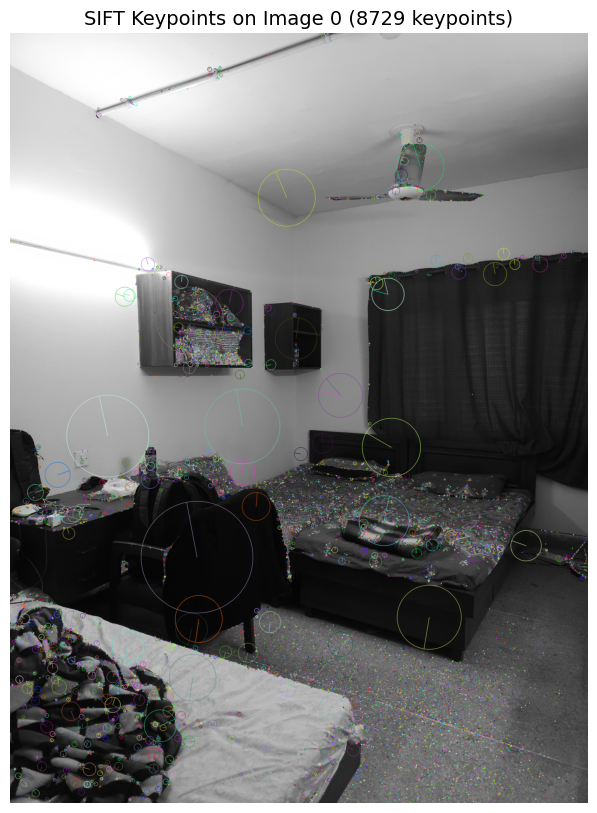

In [12]:

img_with_kp = cv2.drawKeypoints(
    cv2.cvtColor(preprocessed_images[0], cv2.COLOR_RGB2BGR),
    keypoints_list[0],
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints on Image 0 ({len(keypoints_list[0])} keypoints)', fontsize=14)
plt.axis('off')
plt.show()

## 5. Feature Matching Between Consecutive Images

Matching features between 4-5 consecutive image pairs using Lowe's ratio test.

In [13]:
def match_features(desc1, desc2, ratio_thresh=0.7):

    matches = flann.knnMatch(desc1, desc2, k=2)
    
    
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    
    return good_matches

def visualize_matches(img1, kp1, img2, kp2, matches, title=""):
    
    
    img1_bgr = cv2.cvtColor(img1, cv2.COLOR_RGB2BGR)
    img2_bgr = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
    
    
    img_matches = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=14)
    plt.axis('off')
    return img_matches

### 5.1 Match Features Between 4-5 Consecutive Image Pairs

Matching features between 5 consecutive image pairs


--- Matching Image 0 and Image 1 ---
Found 1185 good matches


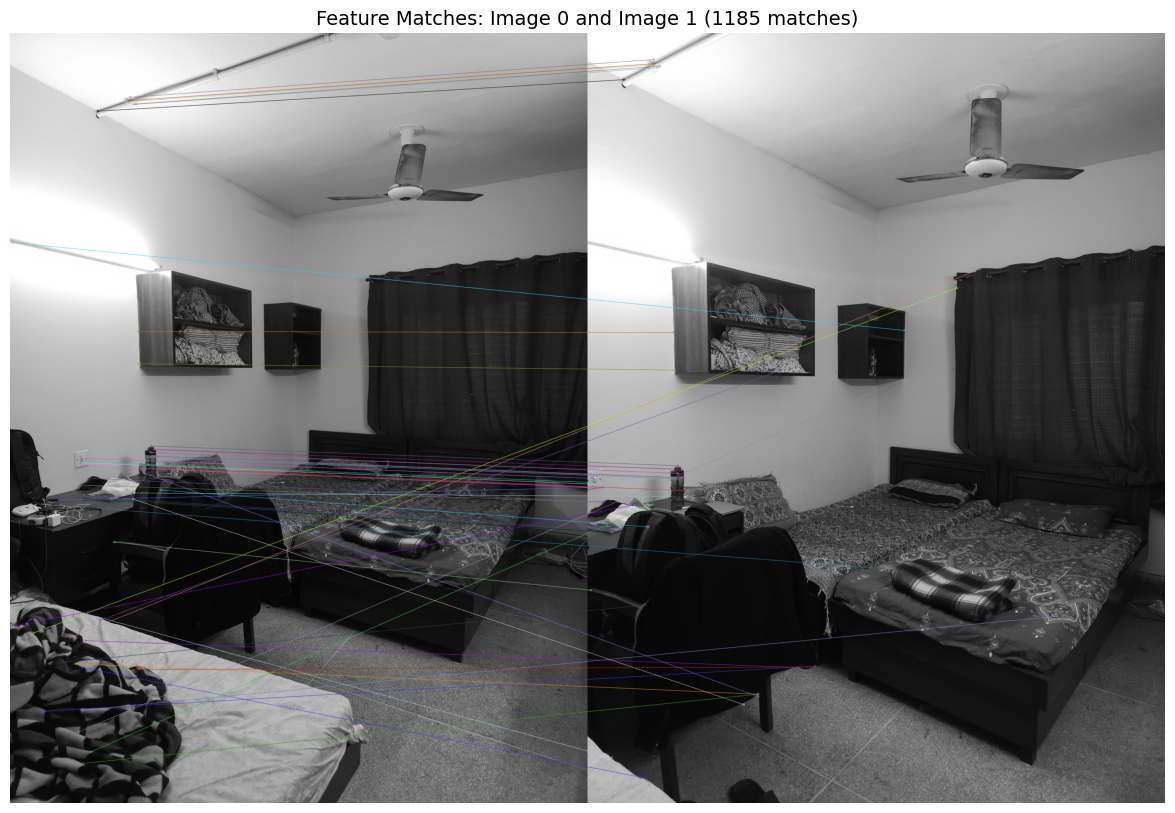


--- Matching Image 1 and Image 2 ---
Found 1087 good matches


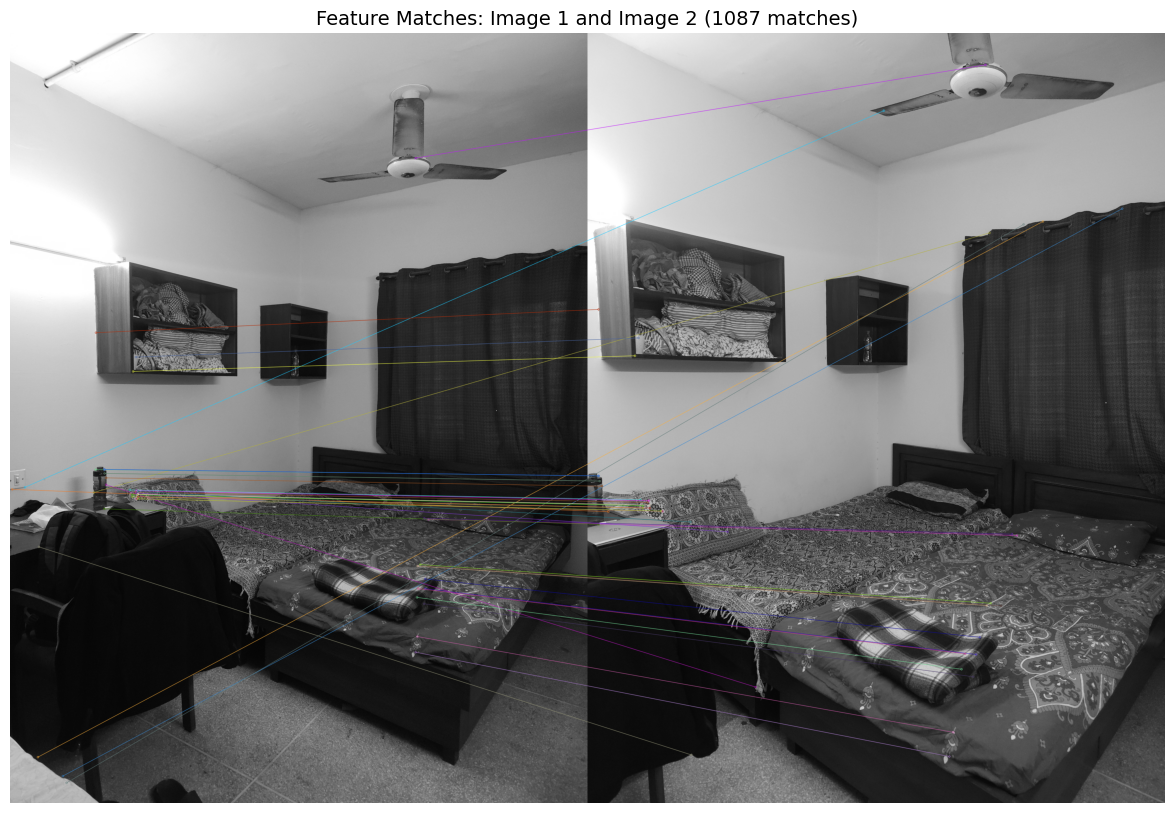


--- Matching Image 2 and Image 3 ---
Found 825 good matches


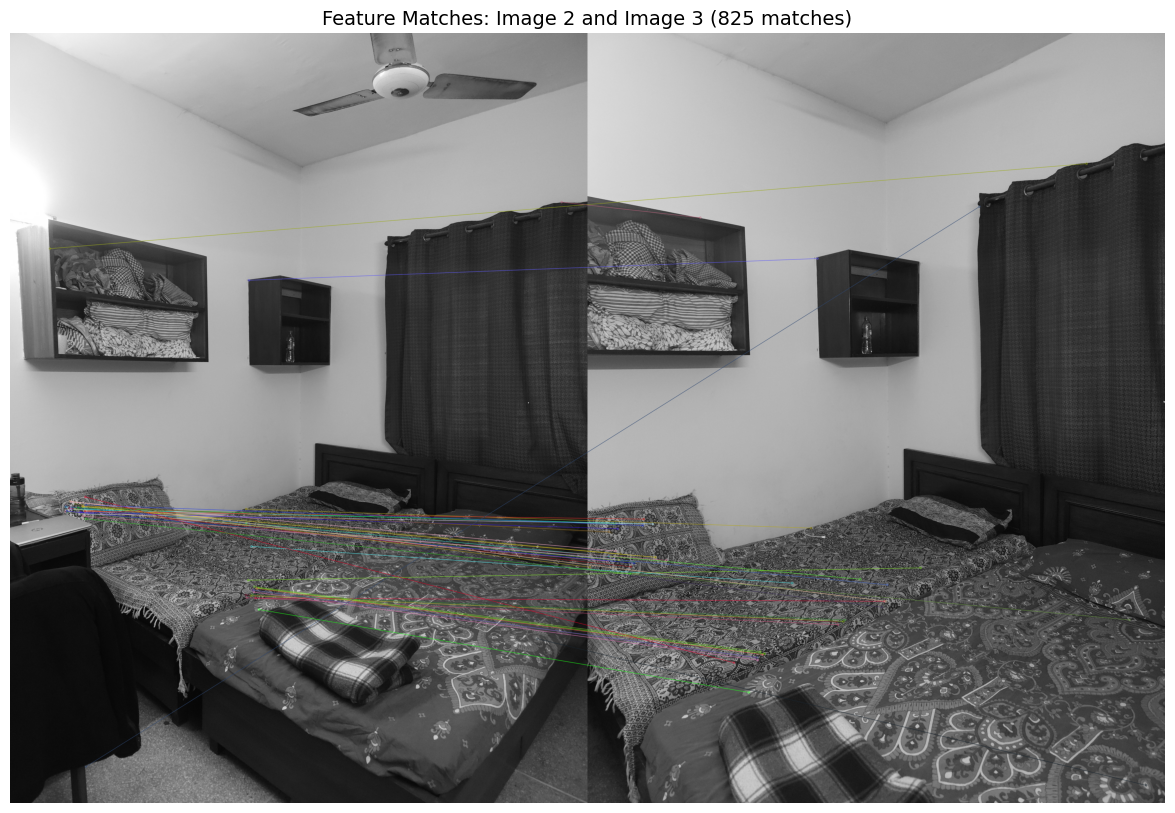


--- Matching Image 3 and Image 4 ---
Found 946 good matches


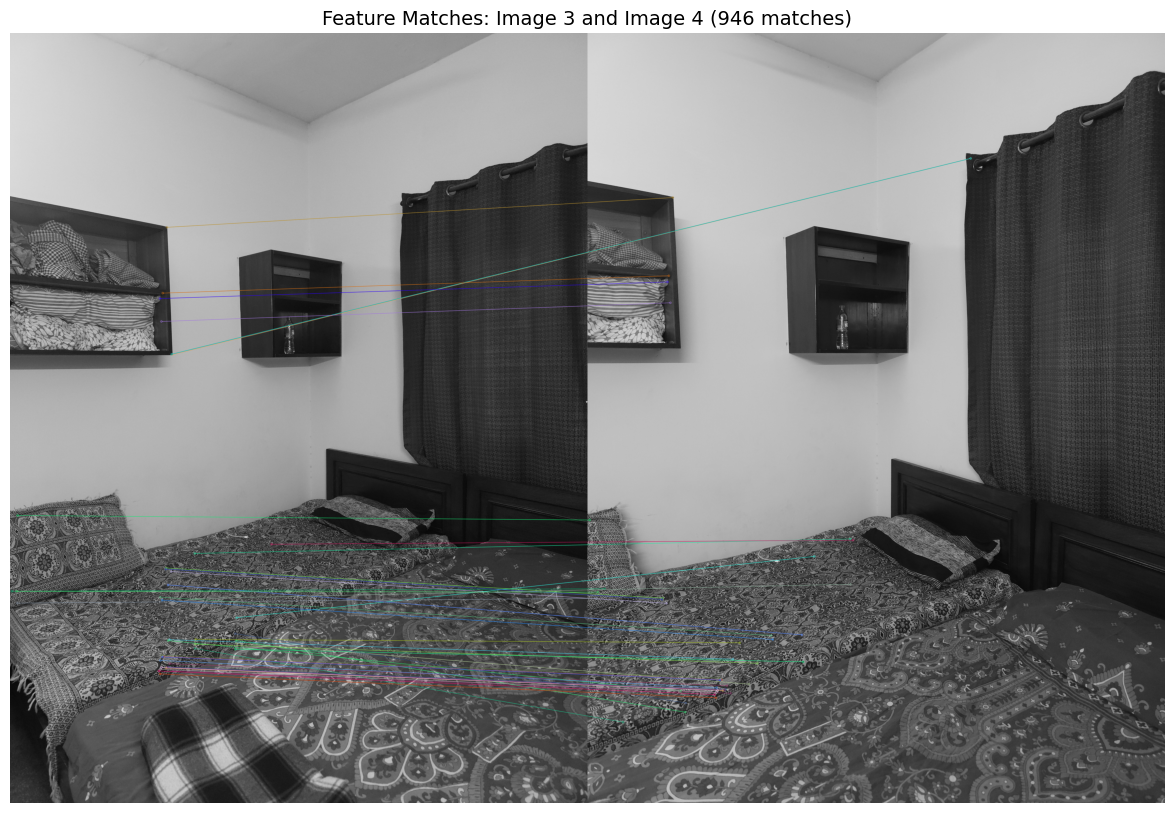


--- Matching Image 4 and Image 5 ---
Found 1065 good matches


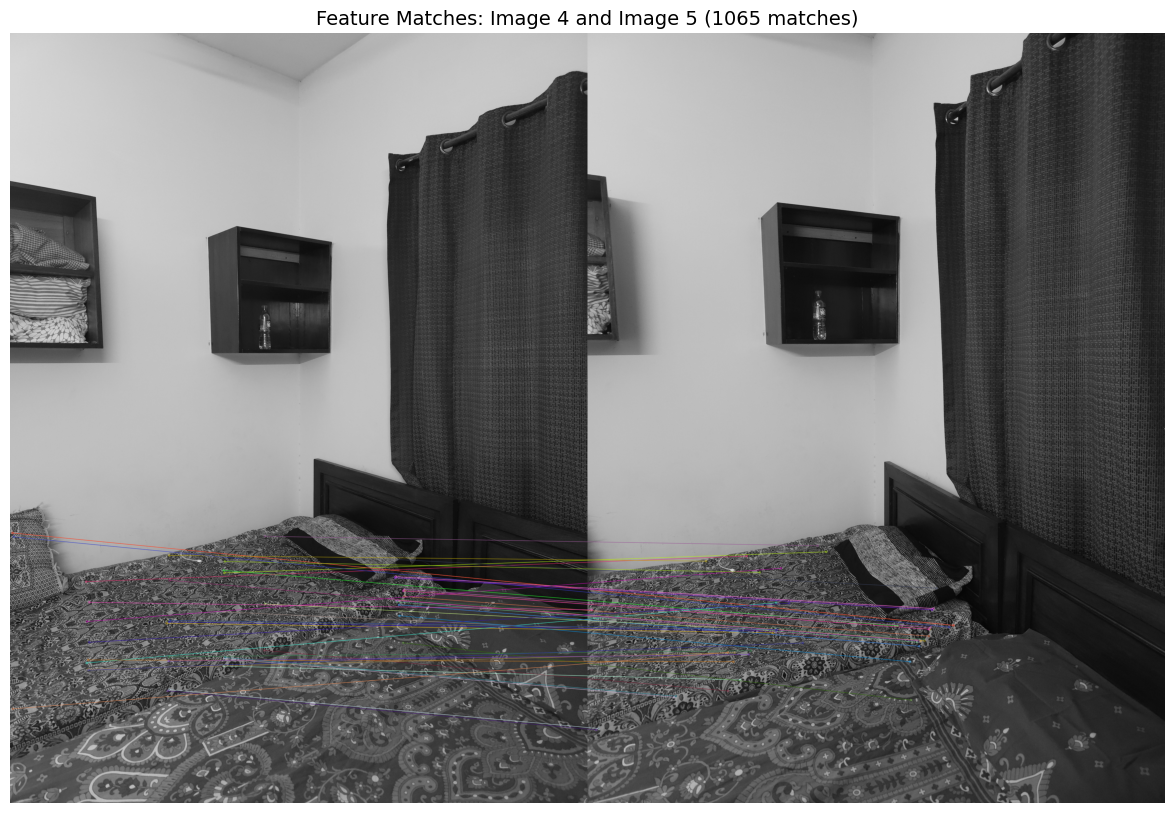

In [14]:

n_pairs = min(5, len(preprocessed_images) - 1)

print(f"Matching features between {n_pairs} consecutive image pairs\n")

for i in range(n_pairs):
    print(f"\n--- Matching Image {i} and Image {i+1} ---")
    
    
    matches = match_features(descriptors_list[i], descriptors_list[i+1])
    
    print(f"Found {len(matches)} good matches")
    
    
    title = f'Feature Matches: Image {i} and Image {i+1} ({len(matches)} matches)'
    visualize_matches(
        preprocessed_images[i], keypoints_list[i],
        preprocessed_images[i+1], keypoints_list[i+1],
        matches, title
    )
    
    

    plt.show()

---

# Week 2: Two-View Reconstruction



In [15]:


img1_gray = preprocessed_images[0]
img2_gray = preprocessed_images[1]
img1_color = images_color[0]
img2_color = images_color[1]

kp1 = keypoints_list[0]
kp2 = keypoints_list[1]
desc1 = descriptors_list[0]
desc2 = descriptors_list[1]

print(f"\nUsing Image 0 and Image 1 for reconstruction")
print(f"Image 1: {len(kp1)} keypoints")
print(f"Image 2: {len(kp2)} keypoints")


matches = match_features(desc1, desc2, ratio_thresh=0.75)
print(f"Found {len(matches)} matches")


Using Image 0 and Image 1 for reconstruction
Image 1: 8729 keypoints
Image 2: 10000 keypoints
Found 1371 matches


In [16]:

def get_camera_intrinsics_from_exif(image_path, img_shape):

    img = Image.open(image_path)
    exif = img._getexif()
    
    if exif is None:
        print("No EXIF data found, using estimation")
        return estimate_camera_intrinsics(img_shape)
    
    
    exif_data = {}
    for tag_id, value in exif.items():
        tag = TAGS.get(tag_id, tag_id)
        exif_data[tag] = value
    
    
    focal_length_mm = float(exif_data.get('FocalLength', 0))
    focal_length_35mm = exif_data.get('FocalLengthIn35mmFilm', 0)
    
    
    orig_width = exif_data.get('ExifImageWidth', img_shape[1])
    orig_height = exif_data.get('ExifImageHeight', img_shape[0])
    
    print(f"Camera: {exif_data.get('Make', 'Unknown')} {exif_data.get('Model', 'Unknown')}")
    print(f"Focal length: {focal_length_mm}mm (35mm equivalent: {focal_length_35mm}mm)")
    print(f"Original image size: {orig_width}x{orig_height}")
    
    
    
    
    if focal_length_35mm > 0:
        
        focal_pixels = (focal_length_35mm / 36.0) * orig_width
    else:
        
        sensor_width_mm = 6.17  
        focal_pixels = (focal_length_mm / sensor_width_mm) * orig_width
    
    
    scale = img_shape[1] / orig_width
    focal_scaled = focal_pixels * scale
    
    
    cx = img_shape[1] / 2.0
    cy = img_shape[0] / 2.0
    
    
    K = np.array([
        [focal_scaled, 0, cx],
        [0, focal_scaled, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def estimate_camera_intrinsics(img_shape):
 
    h, w = img_shape[:2]
    focal_length = max(w, h) * 1.2
    cx = w / 2.0
    cy = h / 2.0
    
    K = np.array([
        [focal_length, 0, cx],
        [0, focal_length, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def filter_points(points_3d, pts1, pts2, R, t, K, max_reproj_error=5.0, max_depth=100.0):
    """Filter 3D points based on validity checks - RELAXED VERSION"""
    valid_mask = np.ones(len(points_3d), dtype=bool)
    
    
    depths1 = points_3d[:, 2]   
    valid_mask &= depths1 > 0
    
    
    points_cam2 = (R @ points_3d.T + t).T
    depths2 = points_cam2[:, 2]
    valid_mask &= depths2 > 0
    
    
    valid_mask &= depths1 < max_depth * 2  
    valid_mask &= depths2 < max_depth * 2
    
    
    points_2d_proj = (K @ points_3d.T).T
    points_2d_proj = points_2d_proj[:, :2] / points_2d_proj[:, 2:3]
    reproj_error1 = np.linalg.norm(points_2d_proj - pts1, axis=1)
    valid_mask &= reproj_error1 < max_reproj_error
    
    
    points_2d_proj2 = (K @ points_cam2.T).T
    points_2d_proj2 = points_2d_proj2[:, :2] / points_2d_proj2[:, 2:3]
    reproj_error2 = np.linalg.norm(points_2d_proj2 - pts2, axis=1)
    valid_mask &= reproj_error2 < max_reproj_error
    
    return valid_mask

In [17]:
print("Camera Intrinsic Matrix K (from EXIF)")
K = get_camera_intrinsics_from_exif(image_paths[0], img1_gray.shape)
print(f"Camera Intrinsic Matrix K:")
print(K)
print(f"Focal length: {K[0,0]:.2f} pixels")
print(f"Principal point: ({K[0,2]:.2f}, {K[1,2]:.2f})")

Camera Intrinsic Matrix K (from EXIF)
Camera: samsung Galaxy S23
Focal length: 5.4mm (35mm equivalent: 23mm)
Original image size: 8160x6120
Camera Intrinsic Matrix K:
[[1.22666667e+03 0.00000000e+00 9.60000000e+02]
 [0.00000000e+00 1.22666667e+03 1.28000000e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Focal length: 1226.67 pixels
Principal point: (960.00, 1280.00)


In [18]:


ratio_thresholds = [0.75, 0.8, 0.85, 0.9]  
ransac_thresholds = [1.0, 1.5, 2.0, 3.0]  
reproj_errors = [10.0, 15.0, 20.0]  

best_params = None
best_points = 0

print("Testing parameter combinations...\n")

for ratio, ransac_th, reproj_err in product(ratio_thresholds, ransac_thresholds, reproj_errors):
    
    test_matches = match_features(descriptors_list[0], descriptors_list[1], ratio_thresh=ratio)
    if len(test_matches) < 8:
        continue
    
    pts1_test = np.float32([keypoints_list[0][m.queryIdx].pt for m in test_matches])
    pts2_test = np.float32([keypoints_list[1][m.trainIdx].pt for m in test_matches])
    K_test = estimate_camera_intrinsics(preprocessed_images[0].shape)
    
    E_test, mask_test = cv2.findEssentialMat(pts1_test, pts2_test, K_test, 
                                              method=cv2.RANSAC, prob=0.999, threshold=ransac_th)
    if E_test is None:
        continue
    
    inliers_test = mask_test.ravel() == 1
    pts1_in = pts1_test[inliers_test]
    pts2_in = pts2_test[inliers_test]
    
    if len(pts1_in) < 8:
        continue
    
    _, R_test, t_test, _ = cv2.recoverPose(E_test, pts1_in, pts2_in, K_test)
    
    P1_test = K_test @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2_test = K_test @ np.hstack([R_test, t_test])
    pts_4d = cv2.triangulatePoints(P1_test, P2_test, pts1_in.T, pts2_in.T)
    pts_3d = (pts_4d[:3] / pts_4d[3]).T
    
    valid = filter_points(pts_3d, pts1_in, pts2_in, R_test, t_test, K_test, max_reproj_error=reproj_err)
    num_valid = np.sum(valid)
    
    if num_valid > best_points:
        best_points = num_valid
        best_params = {'ratio': ratio, 'ransac': ransac_th, 'reproj': reproj_err}
        print(f"New best: {num_valid} points | ratio={ratio}, ransac={ransac_th}, reproj={reproj_err}")

print(f"\n{'='*50}")
print(f"BEST PARAMETERS: {best_params}")
print(f"Expected points: {best_points}")
print(f"{'='*50}")

BEST_RATIO = best_params['ratio']
BEST_RANSAC = best_params['ransac']
BEST_REPROJ = best_params['reproj']

Testing parameter combinations...

New best: 574 points | ratio=0.75, ransac=1.0, reproj=10.0
New best: 591 points | ratio=0.75, ransac=1.0, reproj=15.0
New best: 599 points | ratio=0.75, ransac=1.0, reproj=20.0
New best: 654 points | ratio=0.75, ransac=1.5, reproj=10.0
New best: 716 points | ratio=0.75, ransac=2.0, reproj=10.0
New best: 721 points | ratio=0.75, ransac=2.0, reproj=15.0
New best: 730 points | ratio=0.75, ransac=2.0, reproj=20.0
New best: 806 points | ratio=0.75, ransac=3.0, reproj=10.0
New best: 829 points | ratio=0.75, ransac=3.0, reproj=20.0
New best: 889 points | ratio=0.8, ransac=3.0, reproj=10.0
New best: 922 points | ratio=0.8, ransac=3.0, reproj=15.0
New best: 965 points | ratio=0.85, ransac=3.0, reproj=10.0
New best: 975 points | ratio=0.85, ransac=3.0, reproj=15.0
New best: 1028 points | ratio=0.85, ransac=3.0, reproj=20.0
New best: 1118 points | ratio=0.9, ransac=3.0, reproj=10.0

BEST PARAMETERS: {'ratio': 0.9, 'ransac': 3.0, 'reproj': 10.0}
Expected points: 

## 2. Essential Matrix Estimation

Compute Essential matrix using RANSAC to filter outliers.


Essential Matrix Estimation
Using 1371 matched points
[[-0.0057465  -0.51932131 -0.13975364]
 [ 0.55272455 -0.0145727  -0.41891262]
 [ 0.15077959  0.45457124  0.01293057]]

Inliers after RANSAC: 775 / 1371
Inlier ratio: 56.53%


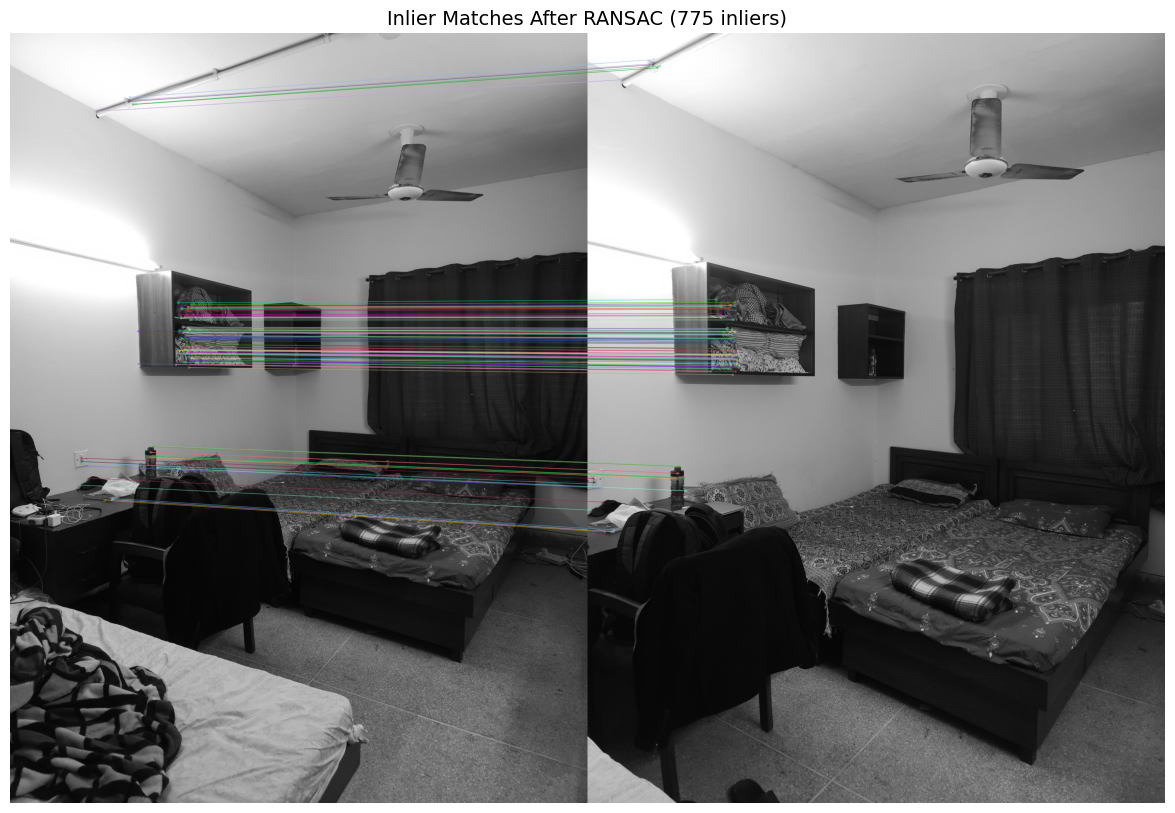

In [19]:

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

print("\nEssential Matrix Estimation")
print(f"Using {len(pts1)} matched points")



E, mask_e = cv2.findEssentialMat(
    pts1, pts2, K, 
    method=cv2.RANSAC, 
    prob=0.999, 
    threshold=BEST_RANSAC  
)


inliers = mask_e.ravel() == 1
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]
matches_inliers = [matches[i] for i in range(len(matches)) if inliers[i]]

print(E)
print(f"\nInliers after RANSAC: {np.sum(inliers)} / {len(pts1)}")
print(f"Inlier ratio: {np.sum(inliers)/len(pts1)*100:.2f}%")


img_inliers = cv2.drawMatches(
    img1_gray, kp1, img2_gray, kp2, matches_inliers[:100], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(img_inliers, cmap='gray')
plt.title(f'Inlier Matches After RANSAC ({len(matches_inliers)} inliers)', fontsize=14)
plt.axis('off')
plt.show()

## 3. Camera Pose Recovery



In [20]:



num_inliers, R, t, mask_pose = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)

print(f"\nRotation Matrix R:")
print(R)
print(f"\nTranslation Vector t:")
print(t.ravel())
print(f"\nNumber of points in front of both cameras: {num_inliers}")


det_R = np.linalg.det(R)
print(f"\nDeterminant of R (should be ~1): {det_R:.6f}")
print(f"R is orthogonal: {np.allclose(R @ R.T, np.eye(3))}")


Rotation Matrix R:
[[ 0.99671789 -0.03113826  0.07472525]
 [ 0.03078679  0.99950885  0.00585104]
 [-0.07487074 -0.00353128  0.99718699]]

Translation Vector t:
[-0.64921688  0.19388358 -0.73547713]

Number of points in front of both cameras: 775

Determinant of R (should be ~1): 1.000000
R is orthogonal: True


## 4. 3D Point Triangulation

Triangulate 3D points from two camera views.

In [21]:




P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])


P2 = K @ np.hstack([R, t])

print("Projection Matrix P1 (Camera 1):")
print(P1)
print("\nProjection Matrix P2 (Camera 2):")
print(P2)


print(f"\nTriangulating {len(pts1_inliers)} points...")
points_4d_hom = cv2.triangulatePoints(P1, P2, pts1_inliers.T, pts2_inliers.T)


points_3d = points_4d_hom[:3] / points_4d_hom[3]
points_3d = points_3d.T  

print(f"Generated {len(points_3d)} 3D points")
print(f"\n3D points statistics:")
print(f"X range: [{points_3d[:, 0].min():.2f}, {points_3d[:, 0].max():.2f}]")
print(f"Y range: [{points_3d[:, 1].min():.2f}, {points_3d[:, 1].max():.2f}]")
print(f"Z range: [{points_3d[:, 2].min():.2f}, {points_3d[:, 2].max():.2f}]")

Projection Matrix P1 (Camera 1):
[[1.22666667e+03 0.00000000e+00 9.60000000e+02 0.00000000e+00]
 [0.00000000e+00 1.22666667e+03 1.28000000e+03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Projection Matrix P2 (Camera 2):
[[ 1.15076470e+03 -4.15863003e+01  1.04896249e+03 -1.50243074e+03]
 [-5.80694142e+01  1.22154414e+03  1.28357663e+03 -7.03580191e+02]
 [-7.48707404e-02 -3.53128386e-03  9.97186995e-01 -7.35477125e-01]]

Triangulating 775 points...
Generated 775 3D points

3D points statistics:
X range: [-2.54, 3.56]
Y range: [-3.55, 2.73]
Z range: [3.48, 8.08]


In [22]:


valid_mask = filter_points(points_3d, pts1_inliers, pts2_inliers, R, t, K, max_reproj_error=BEST_REPROJ)  
points_3d_filtered = points_3d[valid_mask]

print(f"Valid points after filtering: {len(points_3d_filtered)} / {len(points_3d)}")
print(f"Filtered ratio: {len(points_3d_filtered)/len(points_3d)*100:.2f}%")

print(f"Filtered 3D points statistics:")
print(f"X range: [{points_3d_filtered[:, 0].min():.2f}, {points_3d_filtered[:, 0].max():.2f}]")
print(f"Y range: [{points_3d_filtered[:, 1].min():.2f}, {points_3d_filtered[:, 1].max():.2f}]")
print(f"Z range: [{points_3d_filtered[:, 2].min():.2f}, {points_3d_filtered[:, 2].max():.2f}]")

Valid points after filtering: 775 / 775
Filtered ratio: 100.00%
Filtered 3D points statistics:
X range: [-2.54, 3.56]
Y range: [-3.55, 2.73]
Z range: [3.48, 8.08]


## 5. Extract Point Colors

Get RGB colors for each 3D point from the original image.

In [23]:

colors = []
for i, is_valid in enumerate(valid_mask):
    if is_valid:
        x, y = pts1_inliers[i].astype(int)
        
        y = np.clip(y, 0, img1_color.shape[0] - 1)
        x = np.clip(x, 0, img1_color.shape[1] - 1)
        color = img1_color[y, x]
        colors.append(color)

colors = np.array(colors)
print(f"\nExtracted colors for {len(colors)} points")


Extracted colors for 775 points


## 6. 2D Scatter Plots of 3D Point Cloud

Display 2D projections (XY, XZ, YZ) of the reconstructed point cloud.

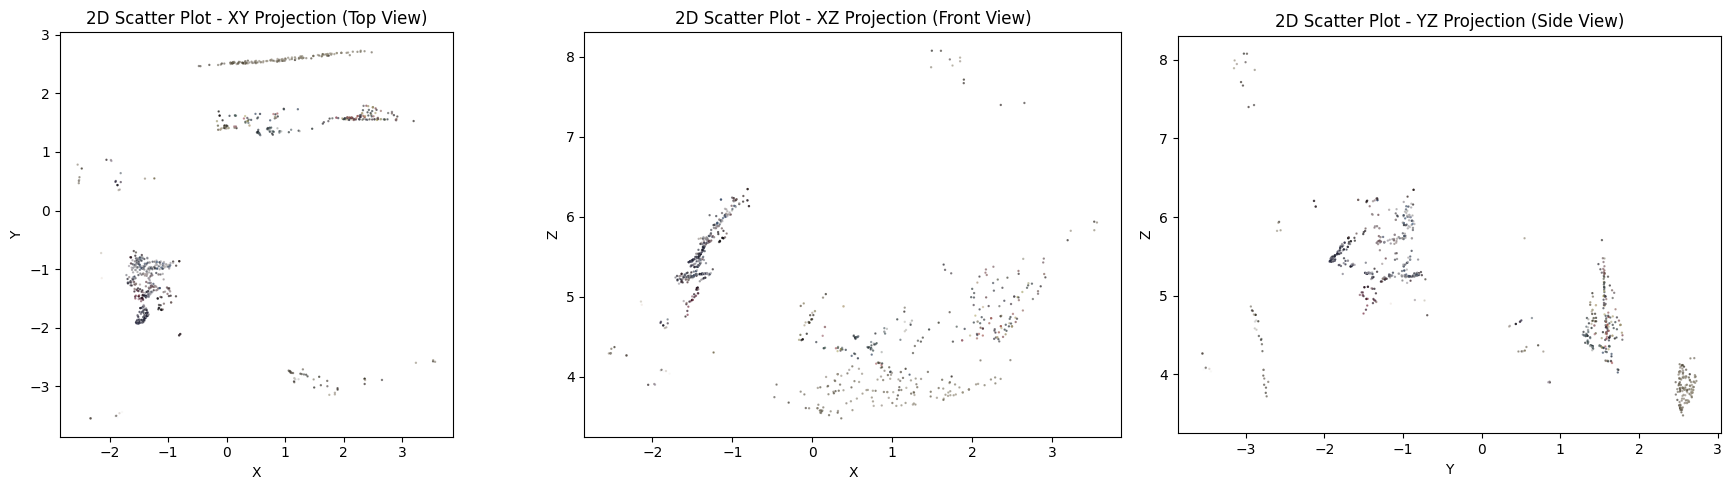

In [24]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 1], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('2D Scatter Plot - XY Projection (Top View)')
axes[0].set_aspect('equal')


axes[1].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].set_title('2D Scatter Plot - XZ Projection (Front View)')
axes[1].set_aspect('equal')


axes[2].scatter(points_3d_filtered[:, 1], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].set_title('2D Scatter Plot - YZ Projection (Side View)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## 7. 3D Point Cloud Visualization

Display the reconstructed point cloud with camera positions.

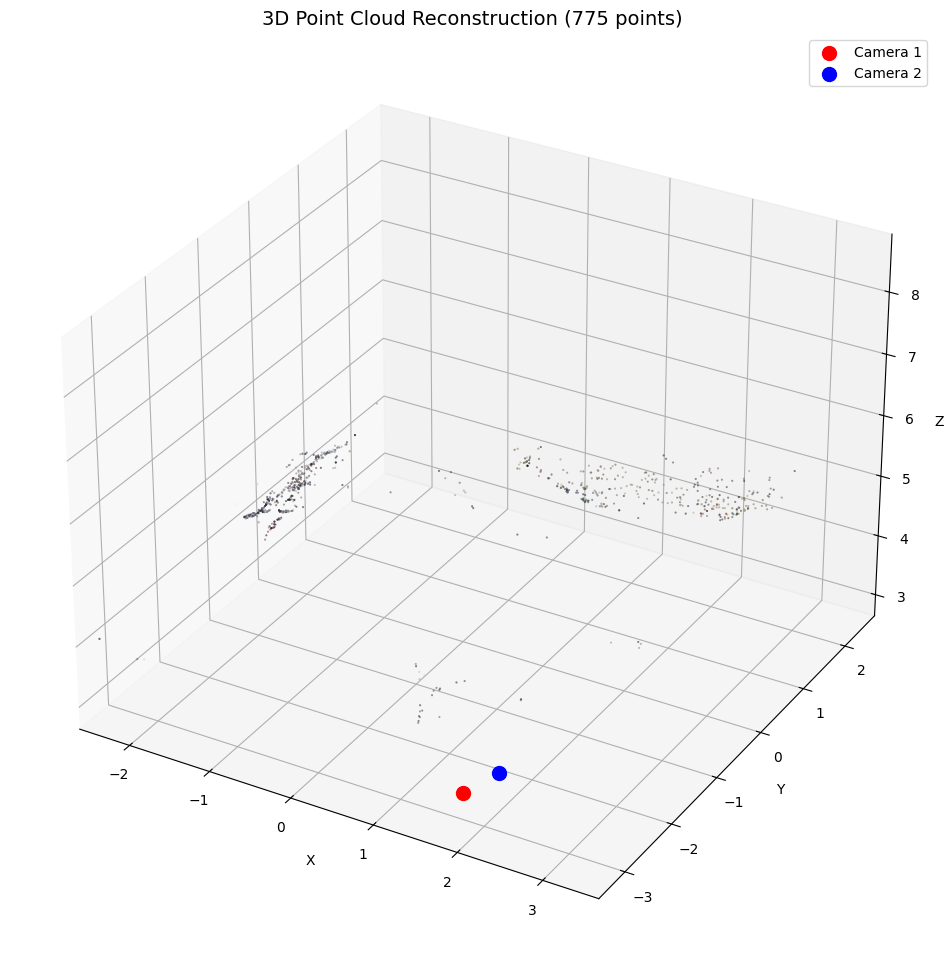

In [25]:

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(
    points_3d_filtered[:, 0], 
    points_3d_filtered[:, 1], 
    points_3d_filtered[:, 2],
    c=colors/255.0,  
    marker='.',
    s=1,
    alpha=0.6
)


ax.scatter([0], [0], [0], c='red', marker='o', s=100, label='Camera 1')
cam2_pos = -R.T @ t
ax.scatter([cam2_pos[0]], [cam2_pos[1]], [cam2_pos[2]], 
           c='blue', marker='o', s=100, label='Camera 2')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D Point Cloud Reconstruction ({len(points_3d_filtered)} points)', fontsize=14)
ax.legend()


max_range = np.array([
    points_3d_filtered[:, 0].max() - points_3d_filtered[:, 0].min(),
    points_3d_filtered[:, 1].max() - points_3d_filtered[:, 1].min(),
    points_3d_filtered[:, 2].max() - points_3d_filtered[:, 2].min()
]).max() / 2.0

mid_x = (points_3d_filtered[:, 0].max() + points_3d_filtered[:, 0].min()) * 0.5
mid_y = (points_3d_filtered[:, 1].max() + points_3d_filtered[:, 1].min()) * 0.5
mid_z = (points_3d_filtered[:, 2].max() + points_3d_filtered[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()

## 8. Save Point Cloud as PLY File

Export the final 3D point cloud to PLY format.

In [26]:
def save_ply(filename, points, colors):
  
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        
        for i in range(len(points)):
            f.write(f"{points[i, 0]:.6f} {points[i, 1]:.6f} {points[i, 2]:.6f} ")
            f.write(f"{int(colors[i, 0])} {int(colors[i, 1])} {int(colors[i, 2])}\n")
    
    print(f"Saved {len(points)} points to {filename}")


save_ply('reconstruction.ply', points_3d_filtered, colors)
print(f"\nPoint cloud saved successfully!")

Saved 775 points to reconstruction.ply

Point cloud saved successfully!


## 9. Inline Point Cloud Visualization

Display the reconstructed point cloud from multiple angles directly in the notebook.

Loaded 775 points from reconstruction.ply


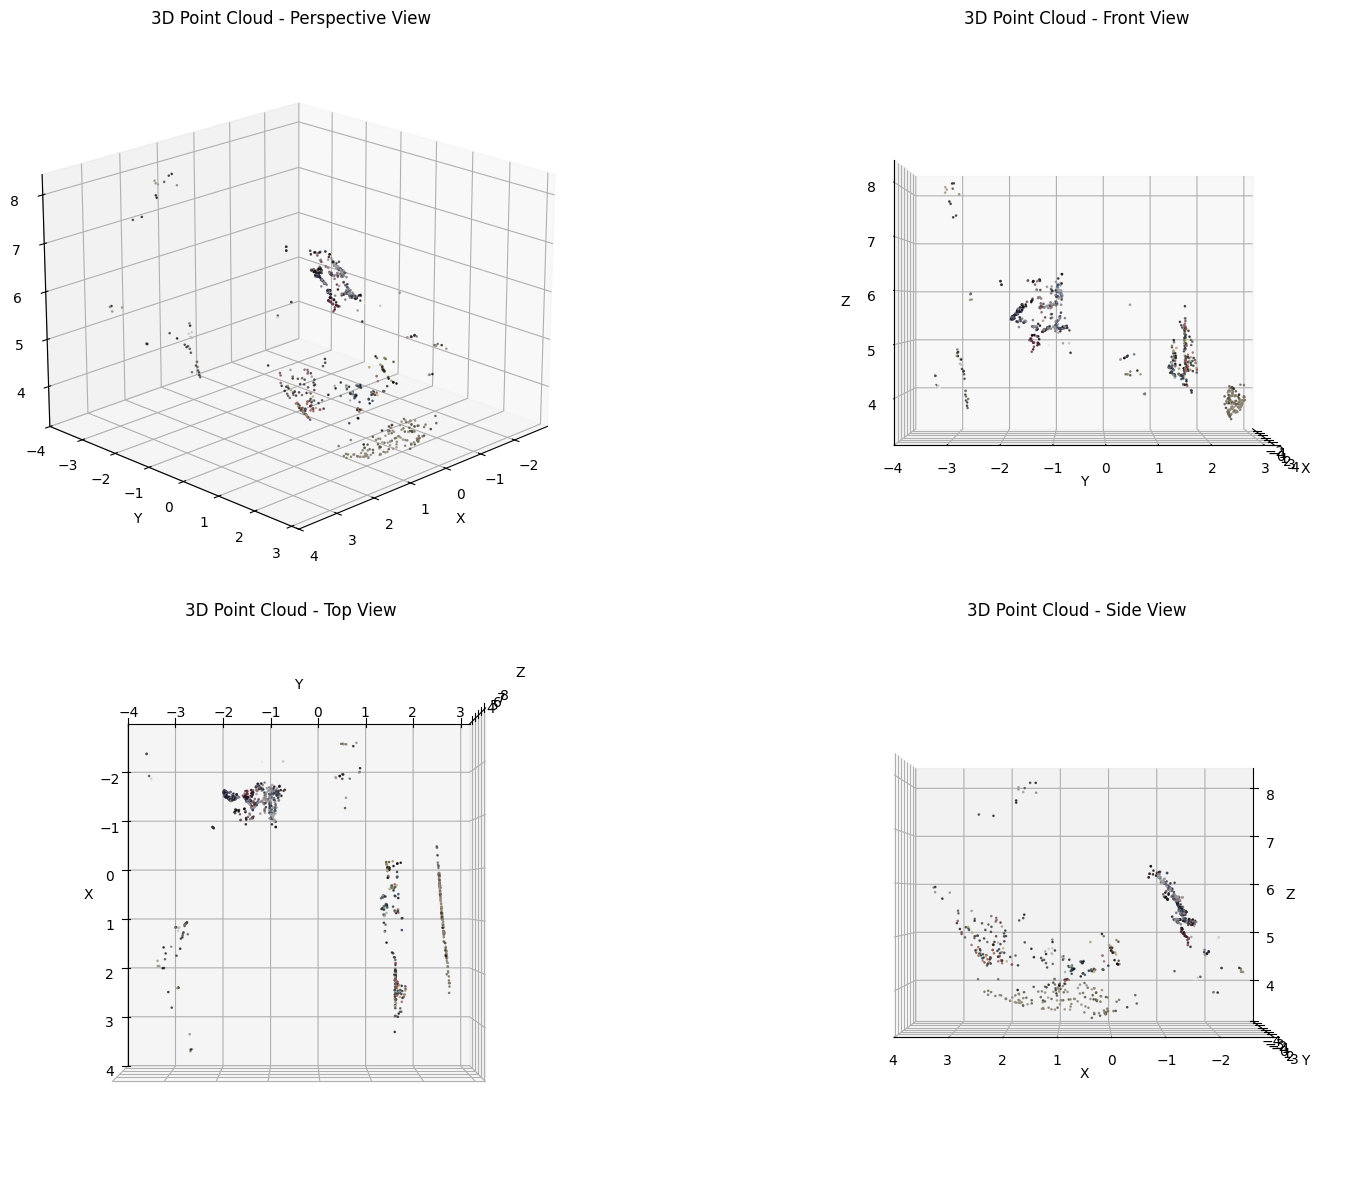


Point cloud visualization complete!
  Total points: 775
  X range: [-2.54, 3.56]
  Y range: [-3.55, 2.73]
  Z range: [3.48, 8.08]


In [27]:



def read_ply(filename):
   
    points = []
    colors = []
    
    with open(filename, 'r') as f:
        
        line = f.readline()
        while 'end_header' not in line:
            line = f.readline()
        
        
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                points.append([float(parts[0]), float(parts[1]), float(parts[2])])
                colors.append([int(parts[3]), int(parts[4]), int(parts[5])])
    
    return np.array(points), np.array(colors)


ply_points, ply_colors = read_ply('reconstruction.ply')
print(f"Loaded {len(ply_points)} points from reconstruction.ply")


fig = plt.figure(figsize=(18, 12))


ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Point Cloud - Perspective View')
ax1.view_init(elev=20, azim=45)


ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Point Cloud - Front View')
ax2.view_init(elev=0, azim=0)


ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('3D Point Cloud - Top View')
ax3.view_init(elev=90, azim=0)


ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('3D Point Cloud - Side View')
ax4.view_init(elev=0, azim=90)

plt.tight_layout()
plt.show()

print(f"\nPoint cloud visualization complete!")
print(f"  Total points: {len(ply_points)}")
print(f"  X range: [{ply_points[:, 0].min():.2f}, {ply_points[:, 0].max():.2f}]")
print(f"  Y range: [{ply_points[:, 1].min():.2f}, {ply_points[:, 1].max():.2f}]")
print(f"  Z range: [{ply_points[:, 2].min():.2f}, {ply_points[:, 2].max():.2f}]")

## 10. Interactive Open3D Visualization

Open the point cloud in an interactive 3D viewer window (requires running the cell).

In [28]:

print("Opening interactive 3D viewer...")
pcd = o3d.io.read_point_cloud("reconstruction.ply")
print(f"Points in reconstruction.ply: {len(pcd.points)}")
o3d.visualization.draw_geometries([pcd], window_name="Two-View Reconstruction")

Opening interactive 3D viewer...
Points in reconstruction.ply: 775
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.



# Week 3: Incremental SfM

## 1. Prepare Data Structures for Incremental SfM

In [48]:
def evaluate_image_pair(idx1, idx2, keypoints_list, descriptors_list, K):
    """
    Evaluate how good an image pair is for initialization.
    Returns: (num_matches, num_inliers, num_3d_points, baseline, score)
    """
    # Match features
    matches = match_features(descriptors_list[idx1], descriptors_list[idx2], ratio_thresh=0.8)
    
    if len(matches) < 100:
        return 0, 0, 0, 0.0, 0.0
    
    # Get matched points
    pts1 = np.float32([keypoints_list[idx1][m.queryIdx].pt for m in matches])
    pts2 = np.float32([keypoints_list[idx2][m.trainIdx].pt for m in matches])
    
    # Estimate Essential Matrix
    E, mask_e = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    
    if E is None:
        return len(matches), 0, 0, 0.0, 0.0
    
    inliers = mask_e.ravel() == 1
    num_inliers = np.sum(inliers)
    
    if num_inliers < 50:
        return len(matches), num_inliers, 0, 0.0, 0.0
    
    pts1_in = pts1[inliers]
    pts2_in = pts2[inliers]
    
    # Recover pose
    _, R, t, mask_pose = cv2.recoverPose(E, pts1_in, pts2_in, K)
    
    # Triangulate
    P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2 = K @ np.hstack([R, t])
    
    points_4d = cv2.triangulatePoints(P1, P2, pts1_in.T, pts2_in.T)
    points_3d = (points_4d[:3] / points_4d[3]).T
    
    # Filter points
    valid_mask = filter_points(points_3d, pts1_in, pts2_in, R, t, K, max_reproj_error=10.0)
    num_valid = np.sum(valid_mask)
    
    # Compute baseline (translation magnitude)
    baseline = np.linalg.norm(t)
    
    # Score: balance between num points and baseline
    # Penalize very small baselines (too close) and very large ones (too far apart)
    if baseline < 0.3:  # Too close
        baseline_score = baseline / 0.3
    elif baseline > 2.0:  # Too far
        baseline_score = 2.0 / baseline
    else:
        baseline_score = 1.0
    
    score = num_valid * baseline_score
    
    return len(matches), num_inliers, num_valid, baseline, score


# ============================================================================
# FIND BEST INITIAL IMAGE PAIR FROM 26 IMAGES
# ============================================================================

print("="*70)
print("FINDING BEST INITIAL IMAGE PAIR FROM 26 IMAGES")
print("="*70)

best_score = 0
best_pair = (0, 1)
results = []

# Strategy: Test pairs with different spacing
# We'll test:
# - Adjacent pairs: (0,1), (1,2), ..., (24,25)
# - Every 2nd: (0,2), (1,3), ..., (23,25)
# - Every 3rd: (0,3), (1,4), ..., (22,25)
# - Every 5th: (0,5), (1,6), ..., (20,25)
# - Some distant pairs: (0,10), (0,15), etc.

test_pairs = []

# Adjacent pairs
for i in range(min(25, len(images)-1)):
    test_pairs.append((i, i+1))

# Every 2nd image
for i in range(min(24, len(images)-2)):
    test_pairs.append((i, i+2))

# Every 3rd image
for i in range(min(23, len(images)-3)):
    test_pairs.append((i, i+3))

# Every 5th image
for i in range(min(21, len(images)-5)):
    test_pairs.append((i, i+5))

# Some strategic distant pairs
strategic_pairs = [
    (0, 8), (0, 10), (0, 12), (0, 15),
    (5, 15), (5, 20),
    (10, 20), (10, 25),
]
for pair in strategic_pairs:
    if pair[0] < len(images) and pair[1] < len(images):
        test_pairs.append(pair)

# Remove duplicates
test_pairs = list(set(test_pairs))

print(f"\nTesting {len(test_pairs)} image pairs...")
print(f"This may take a few minutes...\n")
print(f"{'Pair':<10} {'Matches':<10} {'Inliers':<10} {'3D Points':<12} {'Baseline':<12} {'Score':<10}")
print("-"*70)

for idx1, idx2 in sorted(test_pairs):
    if idx1 >= len(images) or idx2 >= len(images):
        continue
    
    num_matches, num_inliers, num_points, baseline, score = evaluate_image_pair(
        idx1, idx2, keypoints_list, descriptors_list, K
    )
    
    results.append({
        'pair': (idx1, idx2),
        'matches': num_matches,
        'inliers': num_inliers,
        'points': num_points,
        'baseline': baseline,
        'score': score
    })
    
    # Only print promising pairs to reduce clutter
    if score > 50:  # Threshold for "interesting" pairs
        print(f"({idx1:2},{idx2:2}){' '*4} {num_matches:<10} {num_inliers:<10} {num_points:<12} {baseline:<12.3f} {score:<10.2f}")
    
    if score > best_score:
        best_score = score
        best_pair = (idx1, idx2)

print("-"*70)
print(f"\n🏆 BEST PAIR FOUND: Images {best_pair[0]} and {best_pair[1]}")
print(f"   Score: {best_score:.2f}")

# Find best result details
best_result = [r for r in results if r['pair'] == best_pair][0]
print(f"   Matches: {best_result['matches']}")
print(f"   Inliers: {best_result['inliers']}")
print(f"   3D Points: {best_result['points']}")
print(f"   Baseline: {best_result['baseline']:.3f}")

# Show top 5 pairs
print(f"\n📊 Top 5 candidate pairs:")
sorted_results = sorted(results, key=lambda x: x['score'], reverse=True)[:5]
for i, r in enumerate(sorted_results, 1):
    print(f"   {i}. Images {r['pair']}: {r['points']} points, baseline={r['baseline']:.3f}, score={r['score']:.1f}")

print("\n" + "="*70)

FINDING BEST INITIAL IMAGE PAIR FROM 26 IMAGES

Testing 101 image pairs...
This may take a few minutes...

Pair       Matches    Inliers    3D Points    Baseline     Score     
----------------------------------------------------------------------
( 0, 1)     1612       579        579          1.000        579.00    
( 0, 2)     590        175        175          1.000        175.00    
( 1, 2)     1619       685        685          1.000        685.00    
( 1, 3)     410        80         80           1.000        80.00     
( 2, 3)     1453       434        434          1.000        434.00    
( 2, 7)     597        135        135          1.000        135.00    
( 3, 4)     1777       537        536          1.000        536.00    
( 3, 5)     863        75         73           1.000        73.00     
( 3, 8)     638        148        148          1.000        148.00    
( 4, 5)     2157       570        544          1.000        544.00    
( 4, 6)     1138       168        155     

In [49]:
from scipy.optimize import least_squares

# ============================================================================
# INITIALIZE WITH BEST PAIR
# ============================================================================

INIT_IMG1, INIT_IMG2 = best_pair
print(f"\n{'='*70}")
print(f"INITIALIZING RECONSTRUCTION WITH IMAGES {INIT_IMG1} and {INIT_IMG2}")
print(f"{'='*70}\n")

registered_images = {INIT_IMG1, INIT_IMG2}

# Match features for best pair
matches_init = match_features(descriptors_list[INIT_IMG1], descriptors_list[INIT_IMG2], ratio_thresh=0.9)
pts1_init = np.float32([keypoints_list[INIT_IMG1][m.queryIdx].pt for m in matches_init])
pts2_init = np.float32([keypoints_list[INIT_IMG2][m.trainIdx].pt for m in matches_init])

# Essential matrix and pose recovery
E_init, mask_init = cv2.findEssentialMat(pts1_init, pts2_init, K, method=cv2.RANSAC, prob=0.999, threshold=3.0)
inliers_init = mask_init.ravel() == 1
pts1_in = pts1_init[inliers_init]
pts2_in = pts2_init[inliers_init]
matches_inliers_init = [matches_init[i] for i in range(len(matches_init)) if inliers_init[i]]

_, R_init, t_init, _ = cv2.recoverPose(E_init, pts1_in, pts2_in, K)

print(f"Matched features: {len(matches_init)}")
print(f"Inliers: {len(pts1_in)}")
print(f"Baseline: {np.linalg.norm(t_init):.3f}")

# Triangulate for best pair
P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = K @ np.hstack([R_init, t_init])
points_4d_init = cv2.triangulatePoints(P1, P2, pts1_in.T, pts2_in.T)
points_3d_init = (points_4d_init[:3] / points_4d_init[3]).T

# Filter points
valid_mask_init = filter_points(points_3d_init, pts1_in, pts2_in, R_init, t_init, K, max_reproj_error=10.0)
points_3d_init = points_3d_init[valid_mask_init]
pts1_valid = pts1_in[valid_mask_init]
pts2_valid = pts2_in[valid_mask_init]
matches_valid_init = [m for i, m in enumerate(matches_inliers_init) if valid_mask_init[i]]

print(f"Valid 3D points: {len(points_3d_init)}")

# Get colors from first image of the pair
colors_init = np.array([images_color[INIT_IMG1][int(pt[1]), int(pt[0])] for pt in pts1_valid])

# Create poses - DICTIONARY with image indices as keys
pose1 = np.hstack([np.eye(3), np.zeros((3, 1))])
pose2 = np.hstack([R_init, t_init])
poses = {INIT_IMG1: pose1, INIT_IMG2: pose2}

# Initialize point cloud indices
point_cloud_indices = {}
point_cloud_indices[INIT_IMG1] = np.full(len(keypoints_list[INIT_IMG1]), -1, dtype=int)
point_cloud_indices[INIT_IMG2] = np.full(len(keypoints_list[INIT_IMG2]), -1, dtype=int)

# Map keypoints to 3D points
for i, m in enumerate(matches_valid_init):
    point_cloud_indices[INIT_IMG1][m.queryIdx] = i
    point_cloud_indices[INIT_IMG2][m.trainIdx] = i

# Store initial reconstruction
points_3d_map = points_3d_init.copy()
colors_map = colors_init.copy()

print(f"\n✓ Initialization complete!")
print(f"  Starting images: {INIT_IMG1}, {INIT_IMG2}")
print(f"  Initial 3D points: {len(points_3d_map)}")
print(f"  Points range:")
print(f"    X: [{points_3d_map[:, 0].min():.2f}, {points_3d_map[:, 0].max():.2f}]")
print(f"    Y: [{points_3d_map[:, 1].min():.2f}, {points_3d_map[:, 1].max():.2f}]")
print(f"    Z: [{points_3d_map[:, 2].min():.2f}, {points_3d_map[:, 2].max():.2f}]")
print(f"{'='*70}\n")


INITIALIZING RECONSTRUCTION WITH IMAGES 5 and 6

Matched features: 4661
Inliers: 2084
Baseline: 1.000
Valid 3D points: 1992

✓ Initialization complete!
  Starting images: 5, 6
  Initial 3D points: 1992
  Points range:
    X: [-76.67, 1.34]
    Y: [-2.60, 101.09]
    Z: [1.32, 189.90]



In [ ]:
# from scipy.optimize import least_squares

# # Initialize data structures for incremental SfM
# registered_images = {0, 1}  # Images 0 and 1 are already registered from Phase 1

# # poses: list of [R|t] matrices (3x4) for each registered camera
# # First camera at origin, second from Phase 1

# pose1 = np.hstack([np.eye(3), np.zeros((3, 1))])
# pose2 = np.hstack([R, t])
# poses = {0: pose1, 1: pose2} 

# # point_cloud_indices: maps image_idx -> array of 3D point indices for each keypoint
# # -1 means the keypoint doesn't have a 3D point yet
# point_cloud_indices = {}
# point_cloud_indices[0] = np.full(len(keypoints_list[0]), -1, dtype=int)
# point_cloud_indices[1] = np.full(len(keypoints_list[1]), -1, dtype=int)

# # Map the keypoints from Phase 1 two-view reconstruction to 3D points
# for i, m in enumerate(matches_inliers):
#     point_cloud_indices[0][m.queryIdx] = i
#     point_cloud_indices[1][m.trainIdx] = i

# # Use the filtered points from Phase 1
# points_3d_map = points_3d_filtered.copy()
# colors_map = colors.copy()

# print(f"Initial reconstruction state:")
# print(f"  Registered images: {registered_images}")
# print(f"  Number of cameras: {len(poses)}")
# print(f"  Number of 3D points: {len(points_3d_map)}")
# print(f"  Image 0: {np.sum(point_cloud_indices[0] >= 0)} keypoints with 3D points")
# print(f"  Image 1: {np.sum(point_cloud_indices[1] >= 0)} keypoints with 3D points")

Initial reconstruction state:
  Registered images: {0, 1}
  Number of cameras: 2
  Number of 3D points: 775
  Image 0: 775 keypoints with 3D points
  Image 1: 771 keypoints with 3D points


## 2. PnP Function - Add New View

This function localizes a new camera by finding 2D-3D correspondences with already registered images.

In [50]:
def add_view_with_pnp(new_img_idx, registered_images, keypoints_list, descriptors_list,
                      points_3d_map, point_cloud_indices, K, ratio_thresh=0.75, min_matches=20):
    """
    Add a new view to the reconstruction using PnP.
    
    Returns:
        pose: [R|t] camera pose (3x4) or None if failed
    """
    print(f"\n{'='*60}")
    print(f"Attempting to add Image {new_img_idx} using PnP")
    print(f"{'='*60}")
    
    # Collect 2D-3D correspondences by matching with registered images
    points_2d = []
    points_3d_corr = []
    point_3d_indices = []
    
    for reg_img_idx in registered_images:
        # Match features between new image and registered image
        matches = match_features(descriptors_list[new_img_idx], 
                               descriptors_list[reg_img_idx], 
                               ratio_thresh)
        
        # Check which matches have 3D points
        for m in matches:
            kp_idx_new = m.queryIdx
            kp_idx_reg = m.trainIdx
            
            # Does this keypoint in registered image have a 3D point?
            if reg_img_idx in point_cloud_indices:
                pt_3d_idx = point_cloud_indices[reg_img_idx][kp_idx_reg]
                
                if pt_3d_idx >= 0 and pt_3d_idx < len(points_3d_map):
                    # Found a 2D-3D correspondence!
                    pt_2d = keypoints_list[new_img_idx][kp_idx_new].pt
                    points_2d.append(pt_2d)
                    points_3d_corr.append(points_3d_map[pt_3d_idx])
                    point_3d_indices.append(pt_3d_idx)
    
    points_2d = np.array(points_2d, dtype=np.float32)
    points_3d_corr = np.array(points_3d_corr, dtype=np.float32)
    
    print(f"Found {len(points_2d)} 2D-3D correspondences")
    
    if len(points_2d) < min_matches:
        print(f"❌ Not enough correspondences (need {min_matches})")
        return None
    
    # Solve PnP with RANSAC
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        points_3d_corr,
        points_2d,
        K,
        None,  # No distortion
        flags=cv2.SOLVEPNP_ITERATIVE,
        reprojectionError=8.0,
        confidence=0.99
    )
    
    if not success or inliers is None:
        print("❌ PnP failed")
        return None
    
    # Convert rotation vector to matrix
    R_new, _ = cv2.Rodrigues(rvec)
    t_new = tvec
    pose_new = np.hstack([R_new, t_new])
    
    num_inliers = len(inliers)
    inlier_ratio = num_inliers / len(points_2d) * 100
    
    print(f"✓ PnP successful!")
    print(f"  Inliers: {num_inliers} / {len(points_2d)} ({inlier_ratio:.1f}%)")
    print(f"  Rotation:\n{R_new}")
    print(f"  Translation: {t_new.ravel()}")
    
    return pose_new

## 3. Triangulation Function - Add New Points

After adding a camera, triangulate new 3D points between the new view and existing views.

In [51]:
def triangulate_new_points_with_view(new_img_idx, registered_images, poses,
                                   keypoints_list, descriptors_list,
                                   points_3d_map, colors_map, point_cloud_indices,
                                   images_color, K, ratio_thresh=0.75):
    """
    Triangulate new 3D points between newly added camera and existing cameras.
    
    Returns:
        Updated points_3d_map, colors_map, point_cloud_indices
    """
    print(f"\nTriangulating new points with Image {new_img_idx}...")
    
    # Check if new image has a pose
    if new_img_idx not in poses:
        print(f"  Error: Image {new_img_idx} not in poses")
        return points_3d_map, colors_map, point_cloud_indices
    
    new_points = []
    new_colors = []
    new_correspondences = []  # (img1_idx, kp1_idx, img2_idx, kp2_idx)
    
    # Get projection matrix for new image
    P_new = K @ poses[new_img_idx]
    
    # Try triangulating with all registered images
    for reg_img_idx in registered_images:
        if reg_img_idx == new_img_idx:
            continue
        
        # Skip if registered image doesn't have a pose
        if reg_img_idx not in poses:
            continue
        
        # Match features
        matches = match_features(descriptors_list[new_img_idx],
                               descriptors_list[reg_img_idx],
                               ratio_thresh)
        
        if len(matches) < 8:
            continue
        
        # Get projection matrix for registered image
        P_reg = K @ poses[reg_img_idx]
        
        # Only triangulate keypoints that don't have 3D points yet
        valid_matches = []
        for m in matches:
            kp_new = m.queryIdx
            kp_reg = m.trainIdx
            
            already_has_point = False
            if new_img_idx in point_cloud_indices and point_cloud_indices[new_img_idx][kp_new] >= 0:
                already_has_point = True
            if reg_img_idx in point_cloud_indices and point_cloud_indices[reg_img_idx][kp_reg] >= 0:
                already_has_point = True
            
            if not already_has_point:
                valid_matches.append(m)
        
        if len(valid_matches) < 8:
            continue
        
        # Get points
        pts_new = np.float32([keypoints_list[new_img_idx][m.queryIdx].pt for m in valid_matches])
        pts_reg = np.float32([keypoints_list[reg_img_idx][m.trainIdx].pt for m in valid_matches])
        
        # Triangulate
        points_4d = cv2.triangulatePoints(P_reg, P_new, pts_reg.T, pts_new.T)
        points_3d_new = (points_4d[:3] / points_4d[3]).T
        
        # Filter by depth and reprojection error
        R_new = poses[new_img_idx][:, :3]
        t_new = poses[new_img_idx][:, 3:]
        R_reg = poses[reg_img_idx][:, :3]
        t_reg = poses[reg_img_idx][:, 3:]
        
        # Check depth in new camera
        valid_mask = filter_points(points_3d_new, pts_new, pts_reg, R_new, t_new, K, 
                                   max_reproj_error=10.0, max_depth=100.0)
        
        # Also check depth in registered camera
        points_cam_reg = (R_reg @ points_3d_new.T + t_reg).T
        valid_mask &= points_cam_reg[:, 2] > 0
        valid_mask &= points_cam_reg[:, 2] < 100.0
        
        # Check reprojection error in registered camera too
        points_2d_proj_reg = (K @ points_cam_reg.T).T
        points_2d_proj_reg = points_2d_proj_reg[:, :2] / points_2d_proj_reg[:, 2:3]
        reproj_error_reg = np.linalg.norm(points_2d_proj_reg - pts_reg, axis=1)
        valid_mask &= reproj_error_reg < 10.0
        
        # Add valid points
        for i, is_valid in enumerate(valid_mask):
            if is_valid:
                new_points.append(points_3d_new[i])
                pt = pts_new[i]
                color = images_color[new_img_idx][int(pt[1]), int(pt[0])]
                new_colors.append(color)
                
                kp_new = valid_matches[i].queryIdx
                kp_reg = valid_matches[i].trainIdx
                new_correspondences.append((new_img_idx, kp_new, reg_img_idx, kp_reg))
    
    if len(new_points) == 0:
        print("  No new points triangulated")
        return points_3d_map, colors_map, point_cloud_indices
    
    # Add to map
    num_existing = len(points_3d_map)
    new_points = np.array(new_points)
    new_colors = np.array(new_colors)
    
    points_3d_map = np.vstack([points_3d_map, new_points])
    colors_map = np.vstack([colors_map, new_colors])
    
    # Update indices
    for i, (img1_idx, kp1, img2_idx, kp2) in enumerate(new_correspondences):
        pt_idx = num_existing + i
        
        if img1_idx not in point_cloud_indices:
            point_cloud_indices[img1_idx] = np.full(len(keypoints_list[img1_idx]), -1, dtype=int)
        if img2_idx not in point_cloud_indices:
            point_cloud_indices[img2_idx] = np.full(len(keypoints_list[img2_idx]), -1, dtype=int)
        
        point_cloud_indices[img1_idx][kp1] = pt_idx
        point_cloud_indices[img2_idx][kp2] = pt_idx
    
    print(f"  ✓ Added {len(new_points)} new 3D points")
    print(f"  Total points in map: {len(points_3d_map)}")
    
    return points_3d_map, colors_map, point_cloud_indices

## 4. Main Incremental SfM Loop


In [52]:
# ============================================================================
# INCREMENTAL SfM - SMART ORDER (NEIGHBORS FIRST)
# ============================================================================

# Start with initial pair
INIT_IMG1, INIT_IMG2 = best_pair  # e.g., (5, 6)

# Create ordered list: add neighbors first, then expand outward
images_to_add = []

# Add immediate neighbors first
neighbors = []
for offset in [1, -1, 2, -2, 3, -3, 4, -4]:
    for init_img in [INIT_IMG1, INIT_IMG2]:
        neighbor = init_img + offset
        if 0 <= neighbor < len(images) and neighbor not in registered_images:
            if neighbor not in neighbors:
                neighbors.append(neighbor)

# Then add remaining images
remaining = [i for i in range(len(images)) if i not in registered_images and i not in neighbors]

images_to_add = neighbors + remaining

print(f"\n{'#'*70}")
print(f"STARTING INCREMENTAL SfM - SMART ORDER")
print(f"{'#'*70}")
print(f"Initial pair: {sorted(registered_images)}")
print(f"Images to add (in order): {images_to_add[:10]}... (total: {len(images_to_add)})")
print(f"{'#'*70}\n")

reconstruction_stats = []
failed_images = []

for img_idx in images_to_add:
    # Try to add this view
    pose_new = add_view_with_pnp(
        img_idx,
        registered_images,
        keypoints_list,
        descriptors_list,
        points_3d_map,
        point_cloud_indices,
        K,
        ratio_thresh=0.75,
        min_matches=15  # Lowered from 20
    )
    
    if pose_new is None:
        print(f"⚠️  Failed to add image {img_idx} - will retry later\n")
        failed_images.append(img_idx)
        continue
    
    # Successfully added!
    poses[img_idx] = pose_new
    registered_images.add(img_idx)
    
    # Initialize point cloud indices
    if img_idx not in point_cloud_indices:
        point_cloud_indices[img_idx] = np.full(len(keypoints_list[img_idx]), -1, dtype=int)
    
    # Triangulate with VERY RELAXED thresholds
    print(f"Before triangulation: {len(points_3d_map)} points")
    points_3d_map, colors_map, point_cloud_indices = triangulate_new_points_with_view(
        img_idx,
        registered_images,
        poses,
        keypoints_list,
        descriptors_list,
        points_3d_map,
        colors_map,
        point_cloud_indices,
        images_color,
        K,
        ratio_thresh=0.8  # Relaxed
    )
    print(f"After triangulation: {len(points_3d_map)} points (+{len(points_3d_map) - (len(points_3d_map))} new)\n")
    
    # Record stats
    reconstruction_stats.append({
        'image_idx': img_idx,
        'num_cameras': len(registered_images),
        'num_points': len(points_3d_map)
    })
    
    print(f"{'='*70}")
    print(f"✓ Successfully added image {img_idx}")
    print(f"  Registered: {len(registered_images)}/{len(images)} cameras")
    print(f"  Total points: {len(points_3d_map):,}")
    print(f"{'='*70}\n")

# Retry failed images one more time (they might work now with more cameras)
print(f"\n{'#'*70}")
print(f"RETRYING FAILED IMAGES")
print(f"{'#'*70}\n")

for img_idx in failed_images:
    pose_new = add_view_with_pnp(
        img_idx,
        registered_images,
        keypoints_list,
        descriptors_list,
        points_3d_map,
        point_cloud_indices,
        K,
        ratio_thresh=0.75,
        min_matches=15
    )
    
    if pose_new is not None:
        poses[img_idx] = pose_new
        registered_images.add(img_idx)
        
        if img_idx not in point_cloud_indices:
            point_cloud_indices[img_idx] = np.full(len(keypoints_list[img_idx]), -1, dtype=int)
        
        points_3d_map, colors_map, point_cloud_indices = triangulate_new_points_with_view(
            img_idx, registered_images, poses, keypoints_list, descriptors_list,
            points_3d_map, colors_map, point_cloud_indices, images_color, K, ratio_thresh=0.8
        )
        
        print(f"✓ Successfully added image {img_idx} on retry!")
        print(f"  Registered: {len(registered_images)}/{len(images)} cameras")
        print(f"  Total points: {len(points_3d_map):,}\n")

print(f"\n{'#'*70}")
print(f"INCREMENTAL SfM COMPLETE!")
print(f"{'#'*70}")
print(f"Final reconstruction:")
print(f"  Successfully registered: {len(registered_images)}/{len(images)} cameras")
print(f"  Total 3D points: {len(points_3d_map):,}")
print(f"  Registered images: {sorted(registered_images)}")
print(f"  Failed images: {[i for i in range(len(images)) if i not in registered_images]}")
print(f"{'#'*70}\n")


######################################################################
STARTING INCREMENTAL SfM - SMART ORDER
######################################################################
Initial pair: [5, 6]
Images to add (in order): [7, 4, 8, 3, 9, 2, 10, 1, 0, 11]... (total: 24)
######################################################################


Attempting to add Image 7 using PnP
Found 71 2D-3D correspondences
❌ PnP failed
⚠️  Failed to add image 7 - will retry later


Attempting to add Image 4 using PnP
Found 889 2D-3D correspondences
✓ PnP successful!
  Inliers: 364 / 889 (40.9%)
  Rotation:
[[ 0.98711187  0.00791799 -0.15983576]
 [-0.00762039  0.9999679   0.00247478]
 [ 0.15985023 -0.00122487  0.98714052]]
  Translation: [ 1.13515812 -0.03836272  0.60792704]
Before triangulation: 1992 points

Triangulating new points with Image 4...
  ✓ Added 1 new 3D points
  Total points in map: 1993
After triangulation: 1993 points (+0 new)

✓ Successfully added image 4
  Registered: 3/26 came

In [ ]:
# # Configuration
# MAX_IMAGES = 10  # Change to len(images) to process all 26 images

# print(f"\n{'#'*60}")
# print(f"STARTING INCREMENTAL SfM")
# print(f"{'#'*60}")
# print(f"Will attempt to add images 2 to {MAX_IMAGES-1}\n")

# reconstruction_stats = []

# for img_idx in range(2, min(len(images), MAX_IMAGES)):
#     # Try to add this view
#     pose_new = add_view_with_pnp(
#         img_idx,
#         registered_images,
#         keypoints_list,
#         descriptors_list,
#         points_3d_map,
#         point_cloud_indices,
#         K,
#         ratio_thresh=0.75,
#         min_matches=20
#     )
    
#     if pose_new is None:
#         print(f"⚠️  Skipping image {img_idx}\n")
#         continue
    
#     # Successfully added!
#     poses[img_idx] = pose_new
#     registered_images.add(img_idx)
    
#     # Initialize point cloud indices for this image
#     if img_idx not in point_cloud_indices:
#         point_cloud_indices[img_idx] = np.full(len(keypoints_list[img_idx]), -1, dtype=int)
    
#     print(f"\nBefore triangulation: {len(points_3d_map)} points")

#     # Triangulate new points
#     points_3d_map, colors_map, point_cloud_indices = triangulate_new_points_with_view(
#         img_idx,
#         registered_images,
#         poses,
#         keypoints_list,
#         descriptors_list,
#         points_3d_map,
#         colors_map,
#         point_cloud_indices,
#         images_color,
#         K,
#         ratio_thresh=0.75
#     )

#     print(f"After triangulation: {len(points_3d_map)} points (+{len(points_3d_map) - len(points_3d_map)} new)")
    
#     # Record stats
#     reconstruction_stats.append({
#         'image_idx': img_idx,
#         'num_cameras': len(registered_images),
#         'num_points': len(points_3d_map)
#     })
    
#     print(f"\n{'='*60}")
#     print(f"CURRENT STATE:")
#     print(f"  Registered cameras: {len(registered_images)}")
#     print(f"  Total 3D points: {len(points_3d_map)}")
#     print(f"{'='*60}\n")

# print(f"\n{'#'*60}")
# print(f"INCREMENTAL SfM COMPLETE!")
# print(f"{'#'*60}")
# print(f"Final reconstruction:")
# print(f"  Registered cameras: {len(registered_images)} / {len(images)}")
# print(f"  Total 3D points: {len(points_3d_map)}")
# print(f"  Registered image indices: {sorted(registered_images)}")


############################################################
STARTING INCREMENTAL SfM
############################################################
Will attempt to add images 2 to 9


Attempting to add Image 2 using PnP
Found 351 2D-3D correspondences
✓ PnP successful!
  Inliers: 290 / 351 (82.6%)
  Rotation:
[[ 0.98506629 -0.05173452  0.16421921]
 [ 0.05801134  0.99774844 -0.03365612]
 [-0.16210828  0.04268008  0.98584954]]
  Translation: [-1.48218643  0.37195581 -1.52249166]

Before triangulation: 775 points

Triangulating new points with Image 2...
  No new points triangulated
After triangulation: 775 points (+0 new)

CURRENT STATE:
  Registered cameras: 3
  Total 3D points: 775


Attempting to add Image 3 using PnP
Found 70 2D-3D correspondences
✓ PnP successful!
  Inliers: 51 / 70 (72.9%)
  Rotation:
[[ 0.95654902 -0.08492879  0.27892844]
 [ 0.10352392  0.99323517 -0.0525993 ]
 [-0.27257434  0.07918957  0.95887029]]
  Translation: [-2.47994651  0.57953873 -2.14911693]

Before tria

## 5. Visualize Reconstruction Growth

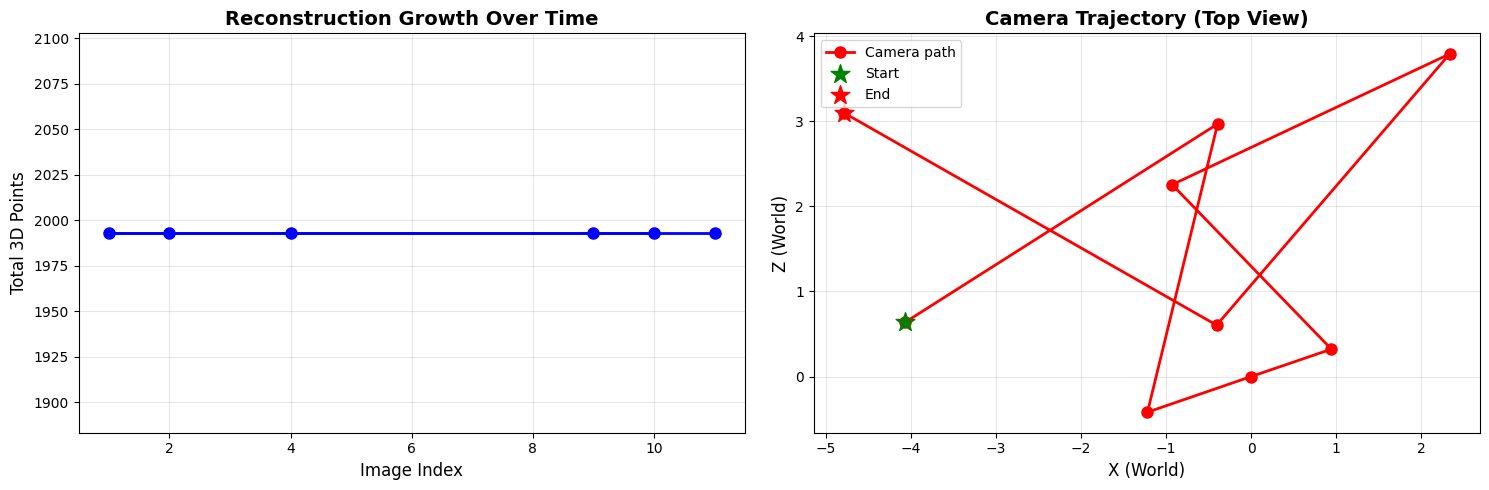


Reconstruction statistics:
  Initial points (2 views): 853
  Final points (9 views): 1993
  Growth: 1140 new points added


In [53]:
if reconstruction_stats:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot point cloud growth
    img_indices = [s['image_idx'] for s in reconstruction_stats]
    num_points = [s['num_points'] for s in reconstruction_stats]
    
    ax1.plot(img_indices, num_points, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Image Index', fontsize=12)
    ax1.set_ylabel('Total 3D Points', fontsize=12)
    ax1.set_title('Reconstruction Growth Over Time', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot camera trajectory (top view)
    camera_positions = []
    for img_idx in sorted(poses.keys()):
        pose = poses[img_idx]
        R = pose[:, :3]
        t = pose[:, 3]
        # Camera center in world coordinates: C = -R^T @ t
        cam_center = -R.T @ t
        camera_positions.append(cam_center.ravel())
    
    camera_positions = np.array(camera_positions)
    
    ax2.plot(camera_positions[:, 0], camera_positions[:, 2], 'ro-', 
             linewidth=2, markersize=8, label='Camera path')
    ax2.scatter(camera_positions[0, 0], camera_positions[0, 2], 
                c='green', s=200, marker='*', label='Start', zorder=5)
    ax2.scatter(camera_positions[-1, 0], camera_positions[-1, 2], 
                c='red', s=200, marker='*', label='End', zorder=5)
    ax2.set_xlabel('X (World)', fontsize=12)
    ax2.set_ylabel('Z (World)', fontsize=12)
    ax2.set_title('Camera Trajectory (Top View)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nReconstruction statistics:")
    print(f"  Initial points (2 views): {853}")
    print(f"  Final points ({len(registered_images)} views): {len(points_3d_map)}")
    print(f"  Growth: {len(points_3d_map) - 853} new points added")

## 6. Save Reconstruction Before Bundle Adjustment

In [54]:
# Save point cloud before BA
ply_file_before = "reconstruction_before_ba.ply"

with open(ply_file_before, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(points_3d_map)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    
    for pt, color in zip(points_3d_map, colors_map):
        f.write(f"{pt[0]} {pt[1]} {pt[2]} ")
        f.write(f"{int(color[0])} {int(color[1])} {int(color[2])}\n")

print(f"✓ Saved {len(points_3d_map)} points to {ply_file_before}")

✓ Saved 1993 points to reconstruction_before_ba.ply


## 7. Bundle Adjustment

Global optimization of all camera poses and 3D points to minimize reprojection error.

In [55]:
def bundle_adjustment(poses, points_3d, point_cloud_indices, keypoints_list, K, max_nfev=50):
    """
    Perform bundle adjustment using Levenberg-Marquardt.
    
    Returns:
        Optimized poses and points_3d
    """
    print(f"\n{'='*60}")
    print("BUNDLE ADJUSTMENT")
    print(f"{'='*60}")
    print(f"Cameras: {len(poses)}")
    print(f"3D points: {len(points_3d)}")
    
    # Build observation list
    observations = []
    camera_indices = []
    point_indices = []
    
    for img_idx in sorted(point_cloud_indices.keys()):
        if img_idx >= len(poses):
            continue
        
        for kp_idx, pt_idx in enumerate(point_cloud_indices[img_idx]):
            if pt_idx >= 0 and pt_idx < len(points_3d):
                kp = keypoints_list[img_idx][kp_idx]
                observations.append([kp.pt[0], kp.pt[1]])
                camera_indices.append(img_idx)
                point_indices.append(pt_idx)
    
    observations = np.array(observations)
    camera_indices = np.array(camera_indices)
    point_indices = np.array(point_indices)
    
    print(f"Total observations: {len(observations)}")
    print(f"Avg observations/camera: {len(observations)/len(poses):.1f}")
    print(f"Avg observations/point: {len(observations)/len(points_3d):.1f}")
    
    # Convert to parameter vector
    camera_params = []
    for img_idx in sorted(poses.keys()):
        pose = poses[img_idx]
        R = pose[:, :3]
        t = pose[:, 3:]
        rvec, _ = cv2.Rodrigues(R)
        camera_params.append(np.concatenate([rvec.ravel(), t.ravel()]))
    
    camera_params = np.concatenate(camera_params)
    point_params = points_3d.ravel()
    x0 = np.concatenate([camera_params, point_params])
    
    print(f"\nOptimization:")
    print(f"  Parameters: {len(x0)} ({len(camera_params)} camera + {len(point_params)} point)")
    print(f"  Starting...\n")
    
    # Residual function
    def residuals(params, n_cams, n_pts, cam_idx, pt_idx, obs, K):
        cam_params = params[:n_cams*6].reshape((n_cams, 6))
        pt_params = params[n_cams*6:].reshape((n_pts, 3))
        
        residuals = []
        for i in range(len(obs)):
            c_idx = cam_idx[i]
            p_idx = pt_idx[i]
            observed = obs[i]
            
            rvec = cam_params[c_idx, :3]
            tvec = cam_params[c_idx, 3:]
            point_3d = pt_params[p_idx]
            
            R, _ = cv2.Rodrigues(rvec)
            pt_cam = R @ point_3d + tvec
            
            if pt_cam[2] <= 0:
                residuals.extend([100.0, 100.0])
                continue
            
            pt_2d = K @ pt_cam
            pt_2d = pt_2d[:2] / pt_2d[2]
            
            error = observed - pt_2d
            residuals.extend([error[0], error[1]])
        
        return np.array(residuals)
    
    # Optimize
    result = least_squares(
        residuals,
        x0,
        args=(len(poses), len(points_3d), camera_indices, point_indices, observations, K),
        method='lm',
        verbose=2,
        max_nfev=max_nfev,
        ftol=1e-4,
        xtol=1e-4
    )
    
    print(f"\n{'='*60}")
    print("OPTIMIZATION COMPLETE")
    print(f"{'='*60}")
    print(f"Success: {result.success}")
    print(f"Message: {result.message}")
    print(f"Iterations: {result.nfev}")
    print(f"Initial cost: {np.sum(result.fun**2):.2f}")
    print(f"Final cost: {result.cost:.2f}")
    print(f"Improvement: {(1 - result.cost/np.sum(result.fun**2))*100:.1f}%")
    
    # Extract optimized parameters
    opt_params = result.x
    cam_params_opt = opt_params[:len(poses)*6].reshape((len(poses), 6))
    pt_params_opt = opt_params[len(poses)*6:].reshape((len(points_3d), 3))
    
    # Convert back to poses
    poses_opt = []
    for cam_param in cam_params_opt:
        rvec = cam_param[:3]
        tvec = cam_param[3:]
        R, _ = cv2.Rodrigues(rvec)
        pose = np.hstack([R, tvec.reshape(3, 1)])
        poses_opt.append(pose)
    
    return poses_opt, pt_params_opt

In [56]:
# Run bundle adjustment
poses_refined, points_3d_refined = bundle_adjustment(
    poses,
    points_3d_map,
    point_cloud_indices,
    keypoints_list,
    K,
    max_nfev=500  # Increase for better refinement (e.g., 100-200)
)

print(f"\nBundle adjustment complete!")
print(f"\nBefore BA - Point cloud range:")
print(f"  X: [{points_3d_map[:, 0].min():.2f}, {points_3d_map[:, 0].max():.2f}]")
print(f"  Y: [{points_3d_map[:, 1].min():.2f}, {points_3d_map[:, 1].max():.2f}]")
print(f"  Z: [{points_3d_map[:, 2].min():.2f}, {points_3d_map[:, 2].max():.2f}]")

print(f"\nAfter BA - Point cloud range:")
print(f"  X: [{points_3d_refined[:, 0].min():.2f}, {points_3d_refined[:, 0].max():.2f}]")
print(f"  Y: [{points_3d_refined[:, 1].min():.2f}, {points_3d_refined[:, 1].max():.2f}]")
print(f"  Z: [{points_3d_refined[:, 2].min():.2f}, {points_3d_refined[:, 2].max():.2f}]")


BUNDLE ADJUSTMENT
Cameras: 9
3D points: 1993
Total observations: 3909
Avg observations/camera: 434.3
Avg observations/point: 2.0

Optimization:
  Parameters: 6033 (54 camera + 5979 point)
  Starting...

The maximum number of function evaluations is exceeded.
Function evaluations 6035, initial cost 2.5504e+10, final cost 2.5504e+10, first-order optimality 3.65e+12.

OPTIMIZATION COMPLETE
Success: False
Message: The maximum number of function evaluations is exceeded.
Iterations: 6035
Initial cost: 51008133659.41
Final cost: 25504066829.70
Improvement: 50.0%

Bundle adjustment complete!

Before BA - Point cloud range:
  X: [-76.67, 1.34]
  Y: [-2.60, 101.09]
  Z: [1.32, 189.90]

After BA - Point cloud range:
  X: [-76.67, 1.34]
  Y: [-2.60, 101.09]
  Z: [1.32, 189.90]


## 8. Save Final Reconstruction

In [ ]:
# Save refined point cloud
ply_file_after = "reconstruction_after_ba.ply"

with open(ply_file_after, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(points_3d_refined)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    
    for pt, color in zip(points_3d_refined, colors_map):
        f.write(f"{pt[0]} {pt[1]} {pt[2]} ")
        f.write(f"{int(color[0])} {int(color[1])} {int(color[2])}\n")

print(f"✓ Saved refined reconstruction to {ply_file_after}")

# Save reconstruction data
import pickle

reconstruction_data = {
    'poses': poses_refined,
    'points_3d': points_3d_refined,
    'colors': colors_map,
    'K': K,
    'registered_images': list(registered_images),
    'point_cloud_indices': point_cloud_indices
}

with open('reconstruction_data.pkl', 'wb') as f:
    pickle.dump(reconstruction_data, f)

print(f"✓ Saved reconstruction data to reconstruction_data.pkl")
print(f"\nAll files saved:")
print(f"  • reconstruction.ply (initial 2-view)")
print(f"  • reconstruction_before_ba.ply (after incremental SfM)")
print(f"  • reconstruction_after_ba.ply (after bundle adjustment)")
print(f"  • reconstruction_data.pkl (all data for further use)")

✓ Saved refined reconstruction to reconstruction_after_ba.ply
✓ Saved reconstruction data to reconstruction_data.pkl

All files saved:
  • reconstruction.ply (initial 2-view)
  • reconstruction_before_ba.ply (after incremental SfM)
  • reconstruction_after_ba.ply (after bundle adjustment)
  • reconstruction_data.pkl (all data for further use)


## 9. Compare Before and After Bundle Adjustment

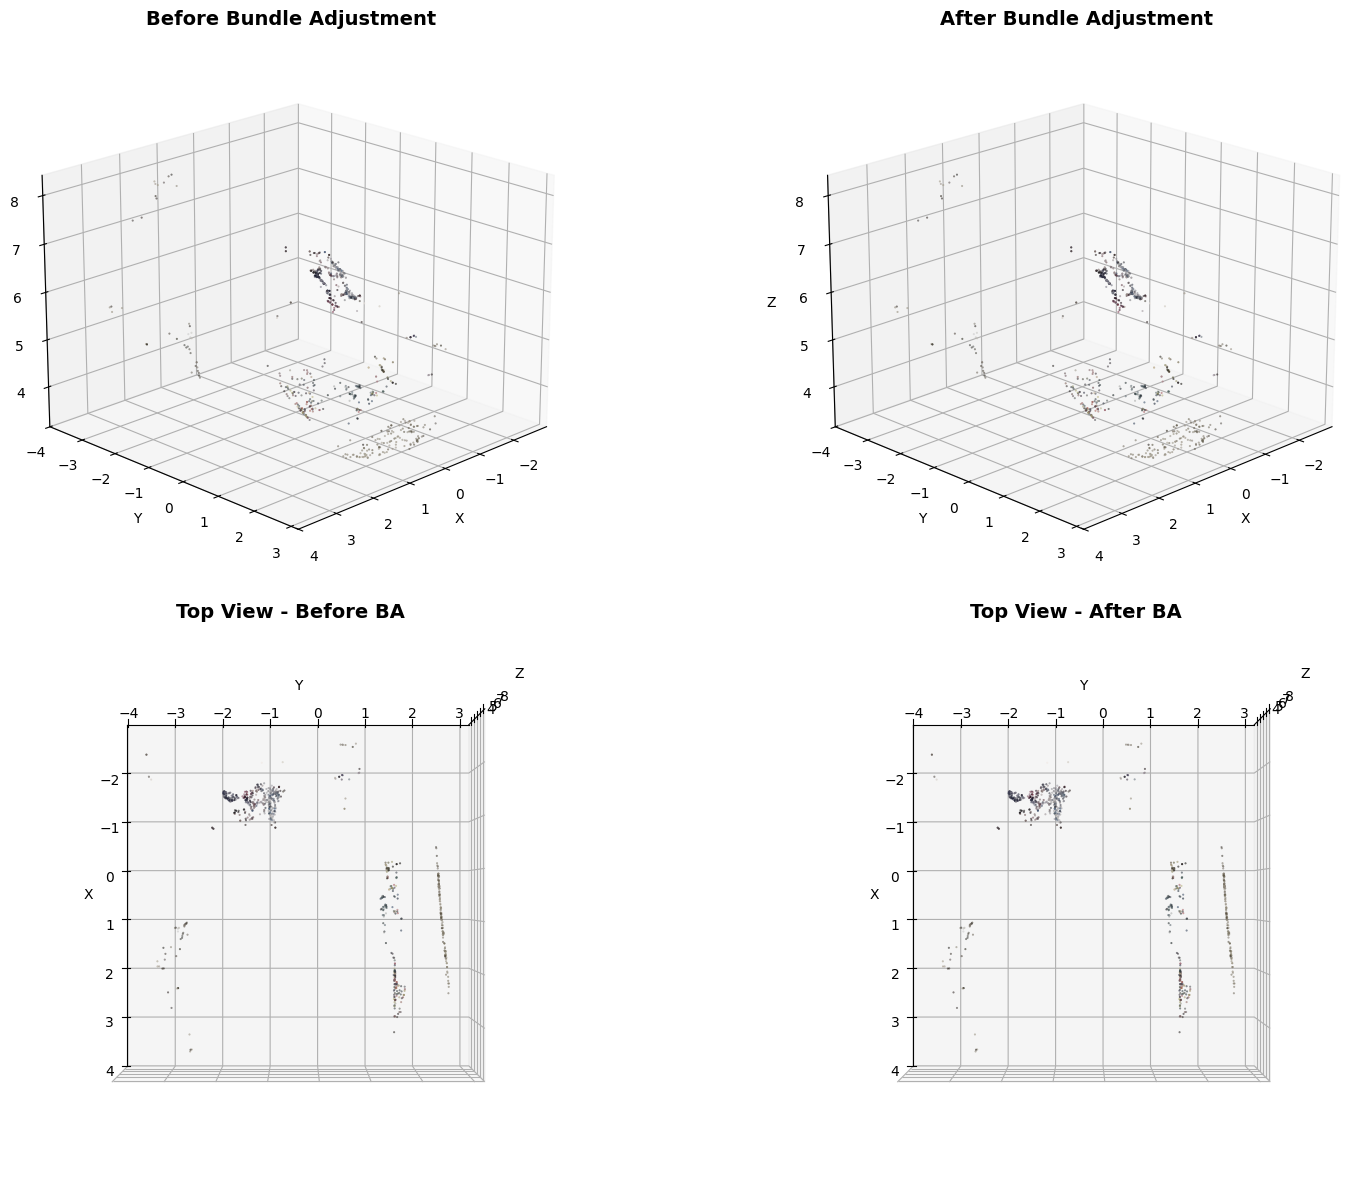


📊 Final Reconstruction Statistics:
Registered cameras: 7 / 26
Total 3D points: 775
Average points per camera: 110.7
Registered image indices: [0, 1, 2, 3, 4, 7, 8]


In [ ]:
fig = plt.figure(figsize=(18, 12))

# Before BA - Perspective
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(points_3d_map[:, 0], points_3d_map[:, 1], points_3d_map[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Before Bundle Adjustment', fontsize=14, fontweight='bold')
ax1.view_init(elev=20, azim=45)

# After BA - Perspective
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(points_3d_refined[:, 0], points_3d_refined[:, 1], points_3d_refined[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('After Bundle Adjustment', fontsize=14, fontweight='bold')
ax2.view_init(elev=20, azim=45)

# Before BA - Top view
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(points_3d_map[:, 0], points_3d_map[:, 1], points_3d_map[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Top View - Before BA', fontsize=14, fontweight='bold')
ax3.view_init(elev=90, azim=0)

# After BA - Top view
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(points_3d_refined[:, 0], points_3d_refined[:, 1], points_3d_refined[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('Top View - After BA', fontsize=14, fontweight='bold')
ax4.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Reconstruction Statistics:")
print(f"{'='*60}")
print(f"Registered cameras: {len(registered_images)} / {len(images)}")
print(f"Total 3D points: {len(points_3d_refined):,}")
print(f"Average points per camera: {len(points_3d_refined)/len(registered_images):.1f}")
print(f"Registered image indices: {sorted(registered_images)}")
print(f"{'='*60}")

## 10. Interactive Visualization with Open3D

In [ ]:
print("Opening interactive 3D viewer for refined reconstruction...")
print("\nControls:")
print("  • Left click + drag: Rotate")
print("  • Mouse wheel: Zoom")
print("  • Right click + drag: Pan")
print("  • Press 'H' for more controls\n")

# Load the refined point cloud
pcd = o3d.io.read_point_cloud("reconstruction_after_ba.ply")
print(f"Points in refined reconstruction: {len(pcd.points):,}")

# Optionally add camera positions as spheres
geometries = [pcd]

for i, pose in enumerate(poses_refined):
    R = pose[:, :3]
    t = pose[:, 3]
    # Camera center: C = -R^T @ t
    cam_center = -R.T @ t
    
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.15)
    sphere.translate(cam_center)
    sphere.paint_uniform_color([1, 0, 0])  # Red for cameras
    geometries.append(sphere)

print(f"Visualizing {len(geometries)-1} cameras and {len(pcd.points):,} points\n")
o3d.visualization.draw_geometries(geometries, 
                                  window_name="Incremental SfM - Final Reconstruction",
                                  width=1200,
                                  height=900)

Opening interactive 3D viewer for refined reconstruction...

Controls:
  • Left click + drag: Rotate
  • Mouse wheel: Zoom
  • Right click + drag: Pan
  • Press 'H' for more controls

Points in refined reconstruction: 775
Visualizing 7 cameras and 775 points

[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
